# **DAT490 Capstone Porject EDA**

## **Introduction & Background:**
This project uses the 2024 BRFSS dataset from the CDC. It contains survey responses from over 400,000 people. We are using this data to see how someone's life situation and their ability to get medical care affect their health.

Having health insurance does not always mean someone can get the care they need. We need to find out if the main problem is the cost of seeing a doctor or other issues like not having a regular clinic. Identifying which of these barriers actually leads to poor health is important. This information helps determine where public health resources should be spent first to have the most impact.

We are focusing on three specific questions:

* **When predicting poor health outcomes (GENHLTH), how does the predictive power of socioeconomic factors (_INCOMG1, _EDUCAG) compare to a person’s health insurance status (_HLTHPL2)?**

* **Among specific barriers to healthcare (such as cost MEDCOST1, lack of a regular doctor PERSDOC3, or delayed checkups CHECKUP1), which factors are the most significant predictors of health decline?**

* **Which machine learning algorithm (Logistic Regression vs. Random Forest/XGBoost) provides the highest accuracy and reliability when using these non-clinical factors? Furthermore, how do data patterns like non-response bias (Refused/Don't Know) affect these models?**

In [64]:
from google.colab import drive
from xgboost import XGBClassifier
#from google.colab import data_table
#data_table.enable_dataframe_formatter()
drive.mount('/content/drive')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [65]:
df_full = pd.read_sas("/content/drive/MyDrive/DAT 490 Group project/LLCP2024.XPT ")

In [66]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [67]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

In [68]:
df_full.head(5)

,_STATE,FMONTH,IDATE,IMONTH,IDAY,IYEAR,DISPCODE,SEQNO,_PSU,CTELENM1,PVTRESD1,COLGHOUS,STATERE1,CELPHON1,LADULT1,NUMADULT,RESPSLC1,LANDSEX3,SAFETIME,CTELNUM1,CELLFON5,CADULT1,CELLSEX3,PVTRESD3,CCLGHOUS,CSTATE1,LANDLINE,HHADULT,SEXVAR,GENHLTH,PHYSHLTH,MENTHLTH,POORHLTH,PRIMINS2,PERSDOC3,MEDCOST1,CHECKUP1,EXERANY2,LASTDEN4,RMVTETH4,CVDINFR4,CVDCRHD4,CVDSTRK3,ASTHMA3,ASTHNOW,CHCSCNC1,CHCOCNC1,CHCCOPD3,ADDEPEV3,CHCKDNY2,HAVARTH4,DIABETE4,DIABAGE4,MARITAL,EDUCA,RENTHOM1,NUMHHOL4,NUMPHON4,CPDEMO1C,VETERAN3,EMPLOY1,CHILDREN,INCOME3,PREGNANT,WEIGHT2,HEIGHT3,DEAF,BLIND,DECIDE,DIFFWALK,DIFFDRES,DIFFALON,HADMAM,HOWLONG,CERVSCRN,CRVCLCNC,CRVCLPAP,CRVCLHPV,HADHYST2,HADSIGM4,COLNSIGM,COLNTES1,SIGMTES1,LASTSIG4,COLNCNCR,VIRCOLO1,VCLNTES2,SMALSTOL,STOLTEST,STOOLDN2,BLDSTFIT,SDNATES1,SMOKE100,SMOKDAY2,USENOW3,ECIGNOW3,LCSFIRST,LCSNUMCG,LCSCTSC1,LCSSCNCR,LCSCTWHN,ALCDAY4,AVEDRNK4,DRNK3GE5,MAXDRNKS,FLUSHOT7,FLSHTMY3,IMFVPLA5,PNEUVAC4,HIVTST7,HIVTSTD3,HIVRISK5,PDIABTS1,PREDIAB2,DIABTYPE,INSULIN1,CHKHEMO3,EYEEXAM1,DIABEYE1,DIABEDU1,FEETSORE,ARTHEXER,SHINGLE2,HPVADVC4,HPVADSH1,TETANUS1,CNCRDIFF,CNCRAGE,CNCRTYP2,CSRVTRT3,CSRVDOC1,CSRVSUM,CSRVRTRN,CSRVINST,CSRVINSR,CSRVDEIN,CSRVCLIN,CSRVPAIN,CSRVCTL2,PSATEST1,PSATIME1,PCPSARS2,PSASUGS1,PCSTALK2,CIMEMLO1,CDWORRY,CDDISCU1,CDHOUS1,CDSOCIA1,CAREGIV1,CRGVREL5,CRGVPRB4,CRGVALZD,CRGVNURS,CRGVPER2,CRGVHOU2,CRGVHRS2,CRGVLNG2,ACEDEPRS,ACEDRINK,ACEDRUGS,ACEPRISN,ACEDIVRC,ACEPUNCH,ACEHURT1,ACESWEAR,ACETOUCH,ACETTHEM,ACEHVSEX,ACEADSAF,ACEADNED,LSATISFY,EMTSUPRT,SDLONELY,SDHEMPLY,FOODSTMP,SDHFOOD1,SDHBILLS,SDHUTILS,SDHTRNSP,HOWSAFE1,MARIJAN1,MARJSMOK,MARJEAT,MARJVAPE,MARJDAB,MARJOTHR,USEMRJN4,LASTSMK2,STOPSMK2,MENTCIGS,MENTECIG,HEATTBCO,SSBSUGR2,SSBFRUT3,FIREARM5,GUNLOAD,LOADULK2,RCSGEND1,RCSXBRTH,RCSRLTN2,CASTHDX2,CASTHNO2,SOMALE,SOFEMALE,HADSEX,PFPPRVN4,TYPCNTR9,NOBCUSE8,QSTVER,QSTLANG,HPVDSHT,ICFQSTVR,_METSTAT,_URBSTAT,MSCODE,_STSTR,_STRWT,_RAWRAKE,_WT2RAKE,_IMPRACE,_CHISPNC,_CRACE1,CAGEG,_CLLCPWT,_DUALUSE,_DUALCOR,_LLCPWT2,_LLCPWT,_RFHLTH,_PHYS14D,_MENT14D,_HLTHPL2,_HCVU654,_TOTINDA,_EXTETH3,_ALTETH3,_DENVST3,_MICHD,_LTASTH1,_CASTHM1,_ASTHMS1,_DRDXAR2,_MRACE1,_HISPANC,_RACE,_RACEG21,_RACEGR3,_RACEPRV,_SEX,_AGEG5YR,_AGE65YR,_AGE80,_AGE_G,HTIN4,HTM4,WTKG3,_BMI5,_BMI5CAT,_RFBMI5,_CHLDCNT,_EDUCAG,_INCOMG1,_RFMAM23,_MAM402Y,_CRVSCRN,_RFPAP37,_HPV5YR1,_PAPHPV1,_HADCOLN,_CLNSCP2,_HADSIGM,_SGMSCP2,_SGMS102,_RFBLDS6,_STOLDN2,_VIRCOL2,_SBONTI2,_CRCREC3,_SMOKER3,_RFSMOK3,_CURECI3,LCSLAST_,LCSNUMC_,_LCSAGE,_LCSYSMK,_PACKDAY,_PACKYRS,_LCSYQTS,_LCSSMKG,_LCSELIG,_LCSCTSN,_LCSPSTF,DRNKANY6,DROCDY4_,_RFBING6,_DRNKWK3,_RFDRHV9,_FLSHOT7,_PNEUMO3,_AIDTST4
0,1.0,2.0,b'02282024',b'02',b'28',b'2024',1100.0,b'2024000001',2.024000e+09,1.0,1.0,NaN,1.0,2.0,1.0,1.0,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,3.0,2.0,88.0,88.0,3.0,2.0,2.0,1.0,1.0,1.0,1.0,2.0,2.0,2.0,2.0,NaN,1.0,2.0,2.0,2.0,2.0,1.0,3.0,NaN,3.0,4.0,1.0,2.0,NaN,1.0,2.0,7.0,88.0,99.0,NaN,131.0,504.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,2.0,1.0,2.0,1.0,2.0,1.0,1.0,1.0,3.0,NaN,NaN,1.0,1.0,7.0,1.0,7.0,2.0,NaN,NaN,2.0,NaN,3.0,1.0,NaN,NaN,1.0,7.0,NaN,888.0,NaN,NaN,NaN,1.0,777777.0,1.0,2.0,2.0,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,5.0,2.0,2.0,5.0,2.0,2.0,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,10.0,1.0,NaN,NaN,1.0,1.0,1.0,11011.0,28.393219,1.0,28.393219,1.0,NaN,NaN,NaN,NaN,1.0,0.465294,220.149005,261.525511,1.0,2.0,1.0,1.0,9.0,1.0,2.0,1.0,1.0,2.0,1.0,1.0,3.0,1.0,1.0,2.0,1.0,1.0,1.0,1.0,2.0,12.0,2.0,78.0,6.0,64.0,163.0,5942.0,2249.0,2.0,1.0,1.0,2.0,9.0,1.0,NaN,1.0,NaN,NaN,NaN,1.0,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,1.0,1.0,NaN,NaN,2.0,NaN,NaN,NaN,NaN,6.0,2.0,NaN,9.0,2.0,5.397605e-79,1.0,5.397605e-79,1.0,1.0,2.0,2.0
1,1.0,2.0,b'02212024',b'02',b'21',b'2024',1100.0,b'2024000002',2.024000e+09,1.

In [69]:
df_full.shape

(457670, 301)

## **Feature Selection**
The original dataset is too large and contains many variables we don't need. We have selected 22 specific features that directly relate to our research questions. This includes our main health indicators, markers for healthcare barriers like cost and doctor availability, and socioeconomic factors like income and education. We also kept basic demographics and chronic disease history to use as controls. This smaller dataset allows us to focus on the actual drivers of health outcomes without the noise of the full survey.

In [70]:
# Outcome
outcome_col = ['GENHLTH']

# Insurance variables
insurance_cols = ['_HLTHPL2', 'PRIMINS2']

# Healthcare access variables
access_cols = ['PERSDOC3', 'MEDCOST1', 'CHECKUP1']

# Socioeconomic variables
ses_cols = ['_INCOMG1', '_EDUCAG', 'EMPLOY1', 'RENTHOM1']

# Demographic variables
demo_cols = ['_AGE_G', 'SEXVAR', '_METSTAT', '_RACEGR3']

selected_colname = outcome_col + insurance_cols + access_cols + ses_cols + demo_cols

df = df_full[selected_colname].copy()
df.head()


,GENHLTH,_HLTHPL2,PRIMINS2,PERSDOC3,MEDCOST1,CHECKUP1,_INCOMG1,_EDUCAG,EMPLOY1,RENTHOM1,_AGE_G,SEXVAR,_METSTAT,_RACEGR3
0,3.0,1.0,3.0,2.0,2.0,1.0,9.0,2.0,7.0,1.0,6.0,2.0,1.0,1.0
1,1.0,1.0,3.0,1.0,2.0,1.0,7.0,4.0,7.0,1.0,6.0,1.0,1.0,1.0
2,2.0,1.0,1.0,3.0,1.0,4.0,9.0,3.0,1.0,1.0,5.0,1.0,2.0,1.0
3,1.0,1.0,3.0,1.0,2.0,1.0,4.0,4.0,7.0,1.0,6.0,1.0,2.0,1.0
4,3.0,1.0,5.0,1.0,2.0,1.0,2.0,3.0,8.0,1.0,4.0,1.0,1.0,1.0


For our revised EDA, we selected variables that align with our updated project focus on non-clinical factors associated with poor health.

**Health Outcome:**
* GENHLTH — General health

**Health Insurance:**
* _HLTHPL2 — Health insurance status
* PRIMINS2 — Primary type of health insurance

**Healthcare Access & Barriers:**
* PERSDOC3 — Personal doctor / Has a regular provider
* MEDCOST1 — Could not see a doctor because of cost
* CHECKUP1 — Time since last routine checkup

**Socioeconomic Factors:**
* _INCOMG1 — Income group
* _EDUCAG — Education level
* EMPLOY1 — Employment status
* RENTHOM1 — Home ownership status
**Demographics:**
* _AGE_G — Age group
* SEXVAR — Sex
* _RACEGR3 — Race/ethnicity
* _METSTAT — Metropolitan status

In [71]:
for col in df.columns:
    print(f"\n===== {col} =====")
    print(df[col].value_counts(dropna=False).sort_index())


===== GENHLTH =====
GENHLTH
1.0     64217
2.0    145791
3.0    156229
4.0     67919
5.0     22204
7.0       915
9.0       390
NaN         5
Name: count, dtype: int64

===== _HLTHPL2 =====
_HLTHPL2
1.0    413720
2.0     25406
9.0     18544
Name: count, dtype: int64

===== PRIMINS2 =====
PRIMINS2
1.0     155360
2.0      38611
3.0     145567
4.0        386
5.0      32847
6.0        144
7.0      16939
8.0       1409
9.0      12329
10.0     10128
77.0     12524
88.0     25406
99.0      6017
NaN          3
Name: count, dtype: int64

===== PERSDOC3 =====
PERSDOC3
1.0    242393
2.0    154558
3.0     56106
7.0      3446
9.0      1164
NaN         3
Name: count, dtype: int64

===== MEDCOST1 =====
MEDCOST1
1.0     43363
2.0    412634
7.0      1229
9.0       438
NaN         6
Name: count, dtype: int64

===== CHECKUP1 =====
CHECKUP1
1.0    370023
2.0     39655
3.0     21480
4.0     18395
7.0      4615
8.0      2783
9.0       717
NaN         2
Name: count, dtype: int64

===== _INCOMG1 =====
_INCOMG1

In [72]:
clean_df = df.copy()

# Recode outcome: GENHLTH
# 1-5 are valid, 7 and 9 are invalid / nonresponse
clean_df['GENHLTH'] = clean_df['GENHLTH'].mask(clean_df['GENHLTH'].isin([7, 9]), pd.NA)

# Recode insurance variables
# _HLTHPL2: 1/2 valid, 9 invalid
clean_df['_HLTHPL2'] = clean_df['_HLTHPL2'].mask(clean_df['_HLTHPL2'].isin([9]), pd.NA)

# PRIMINS2: 1-10 valid categories, 77/88/99 invalid or not applicable
clean_df['PRIMINS2'] = clean_df['PRIMINS2'].mask(clean_df['PRIMINS2'].isin([77, 99]), pd.NA)

# Recode healthcare access variables
# PERSDOC3: 1-3 valid, 7/9 invalid
clean_df['PERSDOC3'] = clean_df['PERSDOC3'].mask(clean_df['PERSDOC3'].isin([7, 9]), pd.NA)

# MEDCOST1: 1/2 valid, 7/9 invalid
clean_df['MEDCOST1'] = clean_df['MEDCOST1'].mask(clean_df['MEDCOST1'].isin([7, 9]), pd.NA)

# CHECKUP1: 1-4 valid, 7/8/9 invalid
clean_df['CHECKUP1'] = clean_df['CHECKUP1'].mask(clean_df['CHECKUP1'].isin([7, 9]), pd.NA)

# Recode socioeconomic variables
# _INCOMG1: 1-7 valid, 9 invalid
clean_df['_INCOMG1'] = clean_df['_INCOMG1'].mask(clean_df['_INCOMG1'].isin([9]), pd.NA)

# _EDUCAG: 1-4 valid, 9 invalid
clean_df['_EDUCAG'] = clean_df['_EDUCAG'].mask(clean_df['_EDUCAG'].isin([9]), pd.NA)

# EMPLOY1: 1-8 valid, 9 invalid
clean_df['EMPLOY1'] = clean_df['EMPLOY1'].mask(clean_df['EMPLOY1'].isin([9]), pd.NA)

# RENTHOM1: 1-3 valid, 7/9 invalid
clean_df['RENTHOM1'] = clean_df['RENTHOM1'].mask(clean_df['RENTHOM1'].isin([7, 9]), pd.NA)

# Recode demographic variables
# _METSTAT: 1/2 valid, missing already appears as NaN
# _RACEGR3: 1-5 valid, 9 invalid
clean_df['_RACEGR3'] = clean_df['_RACEGR3'].mask(clean_df['_RACEGR3'].isin([9]), pd.NA)

# Check value distributions after recoding
for col in clean_df.columns:
    print(f"\n===== {col} =====")
    print(clean_df[col].value_counts(dropna=False).sort_index())


===== GENHLTH =====
GENHLTH
1.0     64217
2.0    145791
3.0    156229
4.0     67919
5.0     22204
NaN      1310
Name: count, dtype: int64

===== _HLTHPL2 =====
_HLTHPL2
1.0    413720
2.0     25406
NaN     18544
Name: count, dtype: int64

===== PRIMINS2 =====
PRIMINS2
1.0     155360
2.0      38611
3.0     145567
4.0        386
5.0      32847
6.0        144
7.0      16939
8.0       1409
9.0      12329
10.0     10128
88.0     25406
NaN      18544
Name: count, dtype: int64

===== PERSDOC3 =====
PERSDOC3
1.0    242393
2.0    154558
3.0     56106
NaN      4613
Name: count, dtype: int64

===== MEDCOST1 =====
MEDCOST1
1.0     43363
2.0    412634
NaN      1673
Name: count, dtype: int64

===== CHECKUP1 =====
CHECKUP1
1.0    370023
2.0     39655
3.0     21480
4.0     18395
8.0      2783
NaN      5334
Name: count, dtype: int64

===== _INCOMG1 =====
_INCOMG1
1.0     20800
2.0     33503
3.0     41702
4.0     49686
5.0    112409
6.0     82453
7.0     29694
NaN     87423
Name: count, dtype: int64

==

## **Data Cleaning**

In [73]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 457670 entries, 0 to 457669
Data columns (total 14 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   GENHLTH   456360 non-null  float64
 1   _HLTHPL2  439126 non-null  float64
 2   PRIMINS2  439126 non-null  float64
 3   PERSDOC3  453057 non-null  float64
 4   MEDCOST1  455997 non-null  float64
 5   CHECKUP1  452336 non-null  float64
 6   _INCOMG1  370247 non-null  float64
 7   _EDUCAG   455307 non-null  float64
 8   EMPLOY1   449268 non-null  float64
 9   RENTHOM1  453726 non-null  float64
 10  _AGE_G    457670 non-null  float64
 11  SEXVAR    457670 non-null  float64
 12  _METSTAT  443047 non-null  float64
 13  _RACEGR3  448567 non-null  float64
dtypes: float64(14)
memory usage: 48.9 MB


In [74]:
summary_table = pd.DataFrame({
    'n_missing': clean_df.isna().sum(),
    'missing_pct': (clean_df.isna().mean() * 100).round(2),
    'n_unique': clean_df.nunique(dropna=True)
}).sort_values(by='missing_pct', ascending=False)

summary_table

,n_missing,missing_pct,n_unique
_INCOMG1,87423,19.10,7
_HLTHPL2,18544,4.05,2
PRIMINS2,18544,4.05,11
_METSTAT,14623,3.20,2
_RACEGR3,9103,1.99,5
EMPLOY1,8402,1.84,8
CHECKUP1,5334,1.17,5
PERSDOC3,4613,1.01,3
RENTHOM1,3944,0.86,3
_EDUCAG,2363,0.52,4


#### **Handling Deplicated Value**

In [75]:
duplicate_count = clean_df.duplicated().sum()
duplicate_ratio = duplicate_count / len(clean_df)
print(f"Total duplicates: {duplicate_count} ({duplicate_ratio:.2%})")

Total duplicates: 226832 (49.56%)


#### **Handling Missing value**

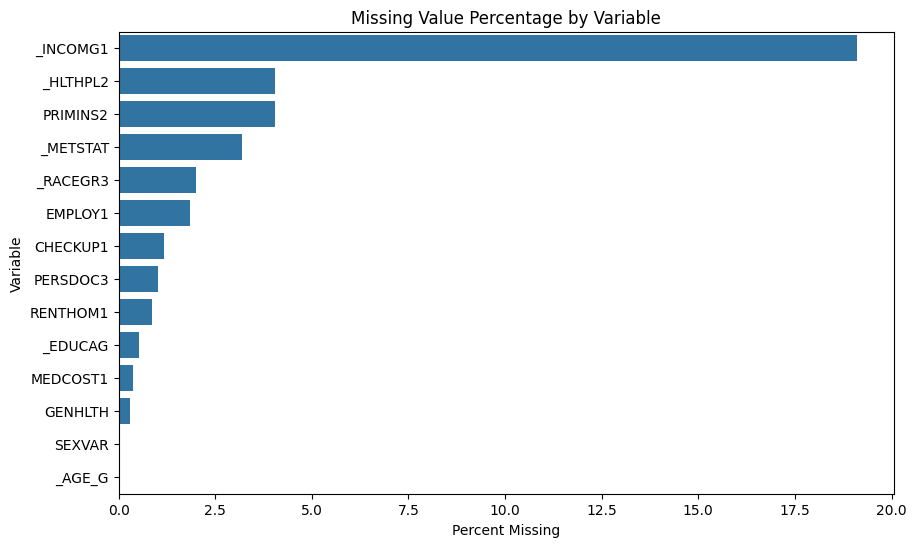

In [76]:
missing_pct = summary_table['missing_pct']

plt.figure(figsize=(10, 6))
sns.barplot(x=missing_pct.values, y=missing_pct.index)

plt.title("Missing Value Percentage by Variable")
plt.xlabel("Percent Missing")
plt.ylabel("Variable")

plt.show()

The missing value profile shows that most retained variables have relatively low missing rates, generally below 5%. However, two key variables have noticeably higher missingness: income group (_INCOMG1), with about 19% missing, and primary insurance type (PRIMINS2), with about 10% missing. Because both variables are central to our research questions, they were retained rather than removed. For lower-missing variables, missingness was reviewed case by case. At this stage, we do not immediately drop all missing rows, since doing so would remove a substantial number of observations and weaken the analysis of socioeconomic and insurance-related factors.

In [77]:
# Drop rows only for low-missing core variables
dropna_cols = [
    'GENHLTH',
    'PERSDOC3',
    'MEDCOST1',
    'CHECKUP1',
    '_EDUCAG',
    'EMPLOY1',
    'RENTHOM1',
    '_METSTAT',
    '_RACEGR3'
]

rows_before = len(clean_df)

clean_df = clean_df.dropna(subset=dropna_cols).copy()

rows_after = len(clean_df)

print("Rows before dropna:", rows_before)
print("Rows after dropna:", rows_after)
print("Rows removed:", rows_before - rows_after)
print("Percent removed:", round((rows_before - rows_after) / rows_before * 100, 2), "%")

Rows before dropna: 457670
Rows after dropna: 413523
Rows removed: 44147
Percent removed: 9.65 %


At this stage, we remove rows with missing values only for low-missing core variables in the cleaned analytic sample. This helps improve data quality while avoiding unnecessary data loss. Variables with higher missingness but strong relevance to our research questions, especially income group (_INCOMG1) and primary insurance type (PRIMINS2), are retained for later handling rather than removed immediately.

#### **Rename Variables for Analysis**

To make the dataset easier to work with, we rename the original BRFSS variable names into clearer and more interpretable labels. This step does not change the data itself. Instead, it helps organize the dataset around the main components of our project: health outcome, insurance, healthcare access barriers, socioeconomic conditions, and demographic characteristics. Using clearer variable names also makes the later EDA, modeling, and interpretation more readable and consistent.

In [78]:
#rename the variables
rename_dict = {
    'GENHLTH': 'general_health',
    '_HLTHPL2': 'has_insurance',
    'PERSDOC3': 'has_personal_doctor',
    'MEDCOST1': 'cost_barrier',
    'CHECKUP1': 'last_checkup_time',
    'PRIMINS2': 'insurance_type',
    '_INCOMG1': 'income_level',
    '_EDUCAG': 'education_level',
    'EMPLOY1': 'employment_status',
    'RENTHOM1': 'home_ownership',
    '_AGE_G': 'age_group',
    'SEXVAR': 'sex',
    '_RACEGR3': 'race_group',
    '_METSTAT': 'is_urban'
}

model_df = clean_df.rename(columns=rename_dict).copy()
model_df.head()

,general_health,has_insurance,insurance_type,has_personal_doctor,cost_barrier,last_checkup_time,income_level,education_level,employment_status,home_ownership,age_group,sex,is_urban,race_group
0,3.0,1.0,3.0,2.0,2.0,1.0,NaN,2.0,7.0,1.0,6.0,2.0,1.0,1.0
1,1.0,1.0,3.0,1.0,2.0,1.0,7.0,4.0,7.0,1.0,6.0,1.0,1.0,1.0
2,2.0,1.0,1.0,3.0,1.0,4.0,NaN,3.0,1.0,1.0,5.0,1.0,2.0,1.0
3,1.0,1.0,3.0,1.0,2.0,1.0,4.0,4.0,7.0,1.0,6.0,1.0,2.0,1.0
4,3.0,1.0,5.0,1.0,2.0,1.0,2.0,3.0,8.0,1.0,4.0,1.0,1.0,1.0


In [79]:
# Create target variable: fair/poor = 1, otherwise = 0
model_df['poor_health'] = model_df['general_health'].replace({
    1.0: 0,  # Excellent
    2.0: 0,  # Very good
    3.0: 0,  # Good
    4.0: 1,  # Fair
    5.0: 1   # Poor
}).astype('Int64')

# Recode insurance status: 1 = insured, 0 = uninsured
model_df['has_insurance'] = model_df['has_insurance'].replace({
    1.0: 1,
    2.0: 0
}).astype('Int64')

# Recode cost barrier: 1 = yes, 0 = no
model_df['cost_barrier'] = model_df['cost_barrier'].replace({
    1.0: 1,
    2.0: 0
}).astype('Int64')

# Recode sex: 1 = male, 2 = female
model_df['is_female'] = model_df['sex'].replace({
    1.0: 0,  # Male
    2.0: 1   # Female
}).astype('Int64')

# Recode metropolitan status: 1 = metropolitan, 0 = nonmetropolitan
model_df['is_urban'] = model_df['is_urban'].replace({
    1.0: 1,
    2.0: 0
}).astype('Int64')

# Quick check
model_df[['general_health', 'poor_health', 'has_insurance', 'cost_barrier', 'sex', 'is_female', 'is_urban']].head()

,general_health,poor_health,has_insurance,cost_barrier,sex,is_female,is_urban
0,3.0,0,1,0,2.0,1,1
1,1.0,0,1,0,1.0,0,1
2,2.0,0,1,1,1.0,0,0
3,1.0,0,1,0,1.0,0,0
4,3.0,0,1,0,1.0,0,1


In [80]:
# Step 3: Recode categorical variables

# Insurance type
model_df['insurance_type'] = model_df['insurance_type'].replace({
    1: 'Employer/Union',
    2: 'Private',
    3: 'Medicare',
    4: 'Medigap',
    5: 'Medicaid',
    6: 'CHIP',
    7: 'Military/VA',
    8: 'Indian Health Service',
    9: 'State-sponsored',
    10: 'Other government program',
    88: 'No coverage'
})
model_df['insurance_type'] = model_df['insurance_type'].fillna('Unknown')

# Grouped insurance type for modeling
model_df['insurance_type_grouped'] = model_df['insurance_type'].replace({
    'Employer/Union': 'Private',
    'Private': 'Private',
    'Medicare': 'Public',
    'Medigap': 'Public',
    'Medicaid': 'Public',
    'CHIP': 'Public',
    'State-sponsored': 'Public',
    'Other government program': 'Public',
    'Military/VA': 'Military/VA',
    'Indian Health Service': 'Other public/tribal',
    'No coverage': 'No coverage',
    'Unknown': 'Unknown'
})

# Personal doctor
model_df['has_personal_doctor'] = model_df['has_personal_doctor'].replace({
    1: 'One',
    2: 'More than one',
    3: 'None'
})

# Last routine checkup
model_df['last_checkup_time'] = model_df['last_checkup_time'].replace({
    1: 'Past year',
    2: '1-2 years',
    3: '2-5 years',
    4: '5+ years',
    8: 'Never'
})

# Income level
model_df['income_level'] = model_df['income_level'].replace({
    1: '<15k',
    2: '15k-25k',
    3: '25k-35k',
    4: '35k-50k',
    5: '50k-100k',
    6: '100k-200k',
    7: '200k+'
})
model_df['income_level'] = model_df['income_level'].fillna('Unknown')

# Education level
model_df['education_level'] = model_df['education_level'].replace({
    1: 'Did not graduate high school',
    2: 'Graduated high school',
    3: 'Attended college/technical school',
    4: 'Graduated college/technical school'
})
model_df['education_level'] = model_df['education_level'].fillna('Unknown')

# Employment status
model_df['employment_status'] = model_df['employment_status'].replace({
    1: 'Employed for wages',
    2: 'Self-employed',
    3: 'Out of work 1+ year',
    4: 'Out of work <1 year',
    5: 'Homemaker',
    6: 'Student',
    7: 'Retired',
    8: 'Unable to work'
})
model_df['employment_status'] = model_df['employment_status'].fillna('Unknown')

# Home ownership
model_df['home_ownership'] = model_df['home_ownership'].replace({
    1: 'Own',
    2: 'Rent',
    3: 'Other arrangement'
})
model_df['home_ownership'] = model_df['home_ownership'].fillna('Unknown')

# Age group
model_df['age_group'] = model_df['age_group'].replace({
    1: '18-24',
    2: '25-34',
    3: '35-44',
    4: '45-54',
    5: '55-64',
    6: '65+'
})

# Race group
model_df['race_group'] = model_df['race_group'].replace({
    1: 'White, non-Hispanic',
    2: 'Black, non-Hispanic',
    3: 'Other race, non-Hispanic',
    4: 'Multiracial, non-Hispanic',
    5: 'Hispanic'
})
model_df['race_group'] = model_df['race_group'].fillna('Unknown')

In [81]:
# Step 4: Quick checks

print(model_df[[
    'general_health', 'poor_health', 'has_insurance', 'insurance_type',
    'insurance_type_grouped', 'has_personal_doctor', 'cost_barrier',
    'last_checkup_time', 'income_level', 'education_level',
    'employment_status', 'home_ownership', 'age_group',
    'sex', 'is_female', 'is_urban', 'race_group'
]].head())

for col in [
    'poor_health',
    'has_insurance',
    'insurance_type',
    'insurance_type_grouped',
    'has_personal_doctor',
    'cost_barrier',
    'last_checkup_time',
    'income_level',
    'education_level',
    'employment_status',
    'home_ownership',
    'age_group',
    'is_female',
    'is_urban',
    'race_group'
]:
    print(f"\n===== {col} =====")
    print(model_df[col].value_counts(dropna=False))

   general_health  poor_health  has_insurance  insurance_type  \
0             3.0            0              1        Medicare   
1             1.0            0              1        Medicare   
2             2.0            0              1  Employer/Union   
3             1.0            0              1        Medicare   
4             3.0            0              1        Medicaid   

  insurance_type_grouped has_personal_doctor  cost_barrier last_checkup_time  \
0                 Public       More than one             0         Past year   
1                 Public                 One             0         Past year   
2                Private                None             1          5+ years   
3                 Public                 One             0         Past year   
4                 Public                 One             0         Past year   

  income_level                     education_level   employment_status  \
0      Unknown               Graduated high school    

In [82]:
final_vars = [
    'poor_health',
    'has_insurance',
    'insurance_type',
    'insurance_type_grouped',
    'has_personal_doctor',
    'cost_barrier',
    'last_checkup_time',
    'income_level',
    'education_level',
    'employment_status',
    'home_ownership',
    'age_group',
    'is_female',
    'is_urban',
    'race_group'
]

final_summary = pd.DataFrame({
    'n_missing': model_df[final_vars].isna().sum(),
    'missing_pct': (model_df[final_vars].isna().mean() * 100).round(2),
    'n_unique': model_df[final_vars].nunique(dropna=True)
}).sort_values(by='missing_pct', ascending=False)

final_summary

,n_missing,missing_pct,n_unique
has_insurance,13758,3.33,2
poor_health,0,0.00,2
insurance_type,0,0.00,12
insurance_type_grouped,0,0.00,6
has_personal_doctor,0,0.00,3
cost_barrier,0,0.00,2
last_checkup_time,0,0.00,5
income_level,0,0.00,8
education_level,0,0.00,4
employment_status,0,0.00,8


In [83]:
model_df = model_df.dropna(subset=['has_insurance']).copy()

print("Final analytic sample size:", len(model_df))
print(model_df['has_insurance'].value_counts(dropna=False))

Final analytic sample size: 399765
has_insurance
1    378042
0     21723
Name: count, dtype: Int64


In [84]:
final_summary = pd.DataFrame({
    'n_missing': model_df[final_vars].isna().sum(),
    'missing_pct': (model_df[final_vars].isna().mean() * 100).round(2),
    'n_unique': model_df[final_vars].nunique(dropna=True)
}).sort_values(by='missing_pct', ascending=False)

final_summary

,n_missing,missing_pct,n_unique
poor_health,0,0.0,2
has_insurance,0,0.0,2
insurance_type,0,0.0,11
insurance_type_grouped,0,0.0,5
has_personal_doctor,0,0.0,3
cost_barrier,0,0.0,2
last_checkup_time,0,0.0,5
income_level,0,0.0,8
education_level,0,0.0,4
employment_status,0,0.0,8


## **1. Target Variable Exploration**


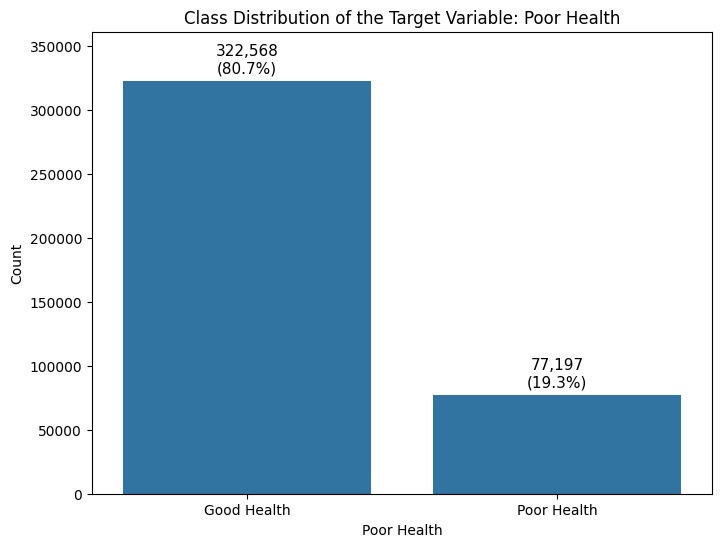

In [85]:
#visualization
count_data = model_df['poor_health'].value_counts().sort_index()
total = count_data.sum()
labels = ['Good Health', 'Poor Health']

plt.figure(figsize=(8, 6))
ax = sns.countplot(x='poor_health', data=model_df)

plt.title('Class Distribution of the Target Variable: Poor Health')
plt.xlabel('Poor Health')
plt.ylabel('Count')
plt.xticks([0, 1], labels)

# Add count and percentage labels on top of bars
for i, count in enumerate(count_data):
    pct = count / total * 100
    ax.text(
        i, count + total * 0.01,
        f'{count:,}\n({pct:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.ylim(0, max(count_data) * 1.12)
plt.show()

### Distribution of the Target Variable

The figure above shows the class distribution of the target variable, `poor_health`. Respondents reporting fair or poor health are coded as 1, while those reporting excellent, very good, or good health are coded as 0. The distribution is moderately imbalanced, with most respondents classified as not being in poor health. Showing both counts and percentages helps us assess class balance before moving to bivariate EDA and predictive modeling.

## **2. Exploring Key Predictor**

### **2.1 Insurance Overview**

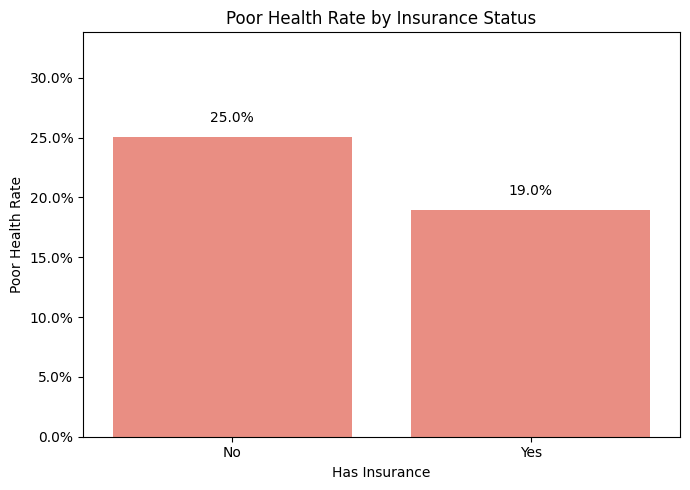

In [86]:
import matplotlib.ticker as mtick

insurance_status_rate = (
    model_df.groupby('has_insurance', dropna=False)['poor_health']
    .mean()
    .reset_index()
    .sort_values('has_insurance')
)

plt.figure(figsize=(7, 5))
ax = sns.barplot(
    data=insurance_status_rate,
    x='has_insurance',
    y='poor_health',
    color='salmon'
)

ax.set_title('Poor Health Rate by Insurance Status')
ax.set_xlabel('Has Insurance')
ax.set_ylabel('Poor Health Rate')
ax.set_xticklabels(['No', 'Yes'])
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylim(0, insurance_status_rate['poor_health'].max() * 1.35)

for i, v in enumerate(insurance_status_rate['poor_health']):
    ax.text(i, v + 0.01, f'{v:.1%}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

### Insurance Status and Poor Health

This figure compares the proportion of respondents classified as being in poor health between those with and without health insurance. Using poor health rates rather than simple counts allows us to compare the relative health risk within each group more directly.

Overall, respondents without insurance show a higher poor health rate than those with insurance. This suggests that insurance coverage is descriptively associated with health risk and provides an initial answer to the insurance-related part of our main research question. However, insurance status alone does not capture all differences in healthcare access or broader socioeconomic disadvantage, so it should be interpreted as only one part of the overall picture.

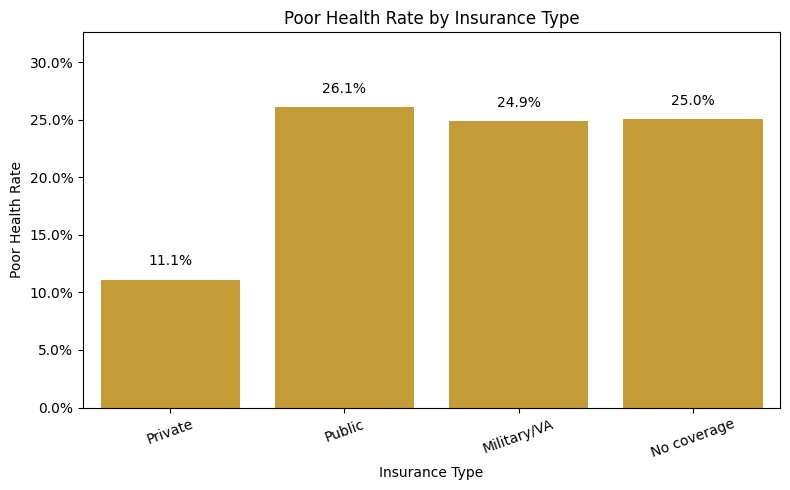

In [87]:
insurance_order = ['Private', 'Public', 'Military/VA', 'No coverage']

insurance_rate = (
    model_df.groupby('insurance_type_grouped')['poor_health']
    .mean()
    .reset_index()
)

insurance_rate = insurance_rate[
    insurance_rate['insurance_type_grouped'].isin(insurance_order)
].copy()

insurance_rate['plot_order'] = insurance_rate['insurance_type_grouped'].map(
    {k: i for i, k in enumerate(insurance_order)}
)

insurance_rate = insurance_rate.sort_values('plot_order')
insurance_rate['poor_health'] = insurance_rate['poor_health'].astype(float)

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=insurance_rate,
    x='insurance_type_grouped',
    y='poor_health',
    order=insurance_order,
    color='goldenrod'
)

ax.set_title('Poor Health Rate by Insurance Type')
ax.set_xlabel('Insurance Type')
ax.set_ylabel('Poor Health Rate')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylim(0, insurance_rate['poor_health'].max() * 1.25)
plt.xticks(rotation=20)

for i, v in enumerate(insurance_rate['poor_health']):
    ax.text(i, v + 0.01, f'{v:.1%}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

### Insurance Type and Poor Health

This figure compares poor health rates across grouped insurance categories. Respondents with private insurance show the lowest observed poor health rate, while those in public insurance categories, military/VA coverage, and no-coverage groups all show substantially higher rates. This suggests that insurance type may provide additional descriptive information beyond simple insured versus uninsured status. At the same time, these differences should be interpreted cautiously, since insurance type may also reflect broader differences in age, socioeconomic position, and health-related needs.

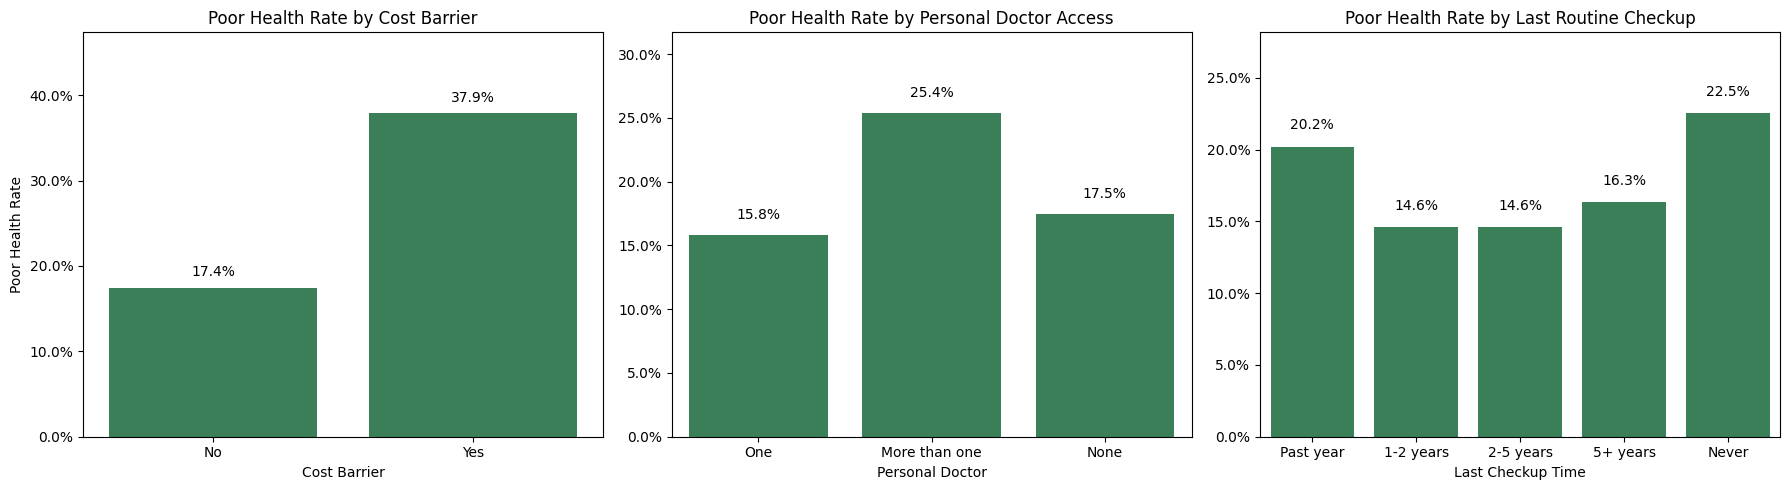

In [88]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Cost barrier vs poor health
cost_order = [0, 1]
cost_rate = (
    model_df.groupby('cost_barrier')['poor_health']
    .mean()
    .reindex(cost_order)
    .reset_index()
)
cost_rate['poor_health'] = cost_rate['poor_health'].astype(float)

sns.barplot(
    data=cost_rate,
    x='cost_barrier',
    y='poor_health',
    color='seagreen',
    ax=axes[0]
)
axes[0].set_title('Poor Health Rate by Cost Barrier')
axes[0].set_xlabel('Cost Barrier')
axes[0].set_ylabel('Poor Health Rate')
axes[0].set_xticklabels(['No', 'Yes'])
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].set_ylim(0, cost_rate['poor_health'].max() * 1.25)

for i, v in enumerate(cost_rate['poor_health']):
    axes[0].text(i, v + 0.01, f'{v:.1%}', ha='center', va='bottom', fontsize=10)

# 2. Personal doctor vs poor health
doctor_order = ['One', 'More than one', 'None']
doctor_rate = (
    model_df.groupby('has_personal_doctor')['poor_health']
    .mean()
    .reindex(doctor_order)
    .reset_index()
)
doctor_rate['poor_health'] = doctor_rate['poor_health'].astype(float)

sns.barplot(
    data=doctor_rate,
    x='has_personal_doctor',
    y='poor_health',
    order=doctor_order,
    color='seagreen',
    ax=axes[1]
)
axes[1].set_title('Poor Health Rate by Personal Doctor Access')
axes[1].set_xlabel('Personal Doctor')
axes[1].set_ylabel('')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].set_ylim(0, doctor_rate['poor_health'].max() * 1.25)

for i, v in enumerate(doctor_rate['poor_health']):
    axes[1].text(i, v + 0.01, f'{v:.1%}', ha='center', va='bottom', fontsize=10)

# 3. Last checkup time vs poor health
checkup_order = ['Past year', '1-2 years', '2-5 years', '5+ years', 'Never']
checkup_rate = (
    model_df.groupby('last_checkup_time')['poor_health']
    .mean()
    .reindex(checkup_order)
    .reset_index()
)
checkup_rate['poor_health'] = checkup_rate['poor_health'].astype(float)

sns.barplot(
    data=checkup_rate,
    x='last_checkup_time',
    y='poor_health',
    order=checkup_order,
    color='seagreen',
    ax=axes[2]
)
axes[2].set_title('Poor Health Rate by Last Routine Checkup')
axes[2].set_xlabel('Last Checkup Time')
axes[2].set_ylabel('')
axes[2].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[2].set_ylim(0, checkup_rate['poor_health'].max() * 1.25)

for i, v in enumerate(checkup_rate['poor_health']):
    axes[2].text(i, v + 0.01, f'{v:.1%}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

The three graphs show that healthcare access is related to poor health, but the patterns are not equally strong. Among the three variables, cost barrier shows the clearest difference: respondents who could not see a doctor because of cost have a much higher poor health rate than those without this barrier. Personal doctor access and last checkup time also show differences, but their patterns are more mixed and less direct. Overall, these results suggest that access-to-care variables, especially affordability, may be important predictors of poor health.

### **Socioeconomic Gradient and Poor Health**

In this step, we examine whether poor health varies systematically across key socioeconomic variables. We focus especially on income and education, since these two factors are most likely to show a clear social gradient and directly support our first sub-question.

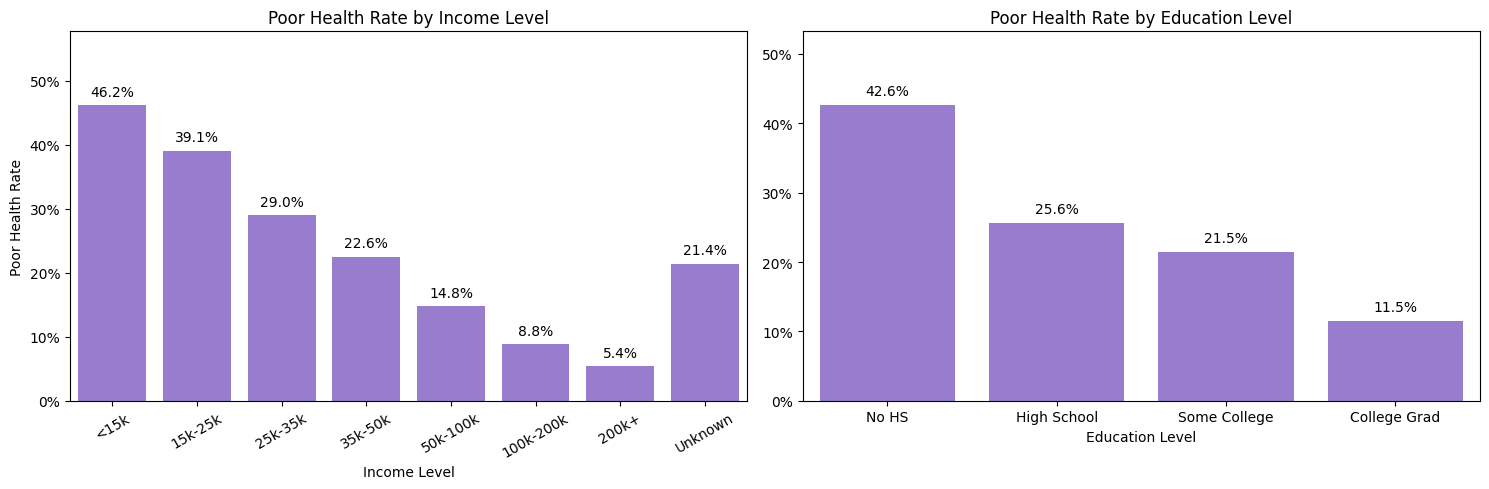

In [89]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Income level vs poor health
income_order = ['<15k', '15k-25k', '25k-35k', '35k-50k', '50k-100k', '100k-200k', '200k+', 'Unknown']
income_rate = (
    model_df.groupby('income_level')['poor_health']
    .mean()
    .reindex(income_order)
    .reset_index()
)
income_rate['poor_health'] = income_rate['poor_health'].astype(float)

sns.barplot(
    data=income_rate,
    x='income_level',
    y='poor_health',
    order=income_order,
    color='mediumpurple',
    ax=axes[0]
)
axes[0].set_title('Poor Health Rate by Income Level')
axes[0].set_xlabel('Income Level')
axes[0].set_ylabel('Poor Health Rate')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].tick_params(axis='x', rotation=30)
axes[0].set_ylim(0, income_rate['poor_health'].max() * 1.25)

for i, v in enumerate(income_rate['poor_health']):
    axes[0].text(i, v + 0.01, f'{v:.1%}', ha='center', va='bottom', fontsize=10)

# 2. Education level vs poor health
education_order = [
    'Did not graduate high school',
    'Graduated high school',
    'Attended college/technical school',
    'Graduated college/technical school'
]
education_rate = (
    model_df.groupby('education_level')['poor_health']
    .mean()
    .reindex(education_order)
    .reset_index()
)
education_rate['poor_health'] = education_rate['poor_health'].astype(float)

sns.barplot(
    data=education_rate,
    x='education_level',
    y='poor_health',
    order=education_order,
    color='mediumpurple',
    ax=axes[1]
)
axes[1].set_title('Poor Health Rate by Education Level')
axes[1].set_xlabel('Education Level')
axes[1].set_ylabel('')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].set_xticklabels(['No HS', 'High School', 'Some College', 'College Grad'])
axes[1].set_ylim(0, education_rate['poor_health'].max() * 1.25)

for i, v in enumerate(education_rate['poor_health']):
    axes[1].text(i, v + 0.01, f'{v:.1%}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

These two graphs show a clear socioeconomic gradient in poor health. For income, the poor health rate is highest in the lowest-income groups and generally decreases as income rises, with the lowest rate appearing in the 200k+ group. Although the Unknown income category is harder to interpret, the overall pattern still strongly suggests that lower income is associated with worse health outcomes. Education shows a similar pattern: respondents with less education have higher poor health rates, while college graduates have the lowest rate. Overall, these results suggest that socioeconomic disadvantage, especially lower income and lower educational attainment, is strongly associated with poor health.

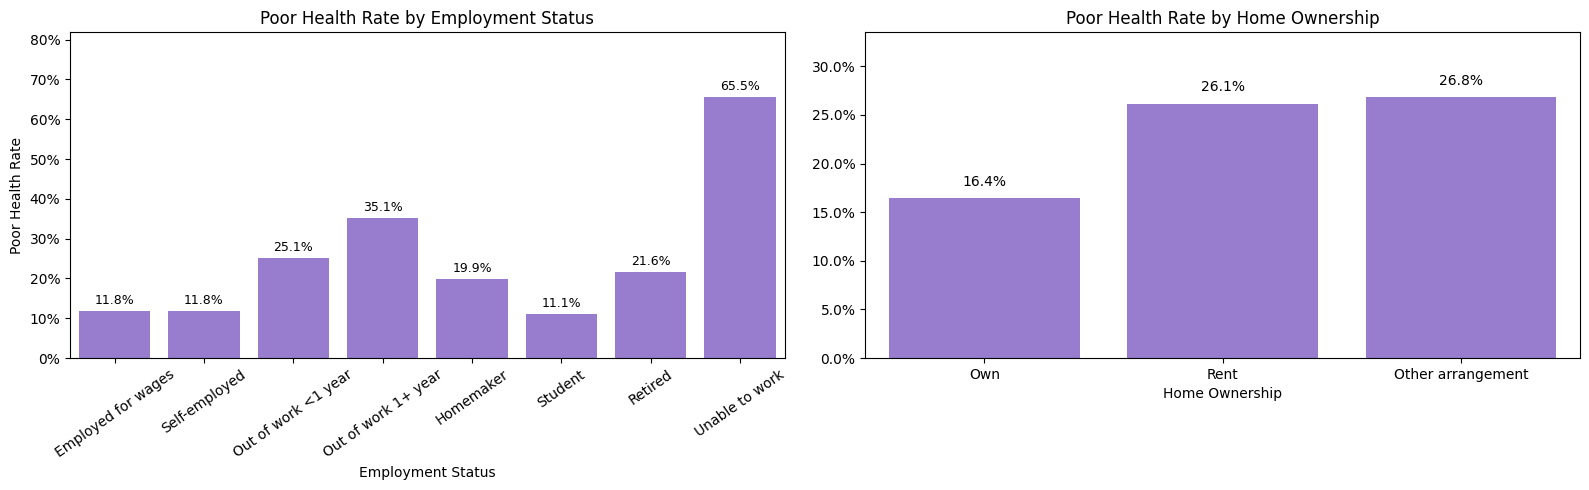

In [90]:

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Employment status vs poor health
employment_order = [
    'Employed for wages',
    'Self-employed',
    'Out of work <1 year',
    'Out of work 1+ year',
    'Homemaker',
    'Student',
    'Retired',
    'Unable to work'
]

employment_rate = (
    model_df.groupby('employment_status')['poor_health']
    .mean()
    .reindex(employment_order)
    .reset_index()
)
employment_rate['poor_health'] = employment_rate['poor_health'].astype(float)

sns.barplot(
    data=employment_rate,
    x='employment_status',
    y='poor_health',
    order=employment_order,
    color='mediumpurple',
    ax=axes[0]
)
axes[0].set_title('Poor Health Rate by Employment Status')
axes[0].set_xlabel('Employment Status')
axes[0].set_ylabel('Poor Health Rate')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].tick_params(axis='x', rotation=35)
axes[0].set_ylim(0, employment_rate['poor_health'].max() * 1.25)

for i, v in enumerate(employment_rate['poor_health']):
    axes[0].text(i, v + 0.01, f'{v:.1%}', ha='center', va='bottom', fontsize=9)

# 2. Home ownership vs poor health
home_order = ['Own', 'Rent', 'Other arrangement']

home_rate = (
    model_df.groupby('home_ownership')['poor_health']
    .mean()
    .reindex(home_order)
    .reset_index()
)
home_rate['poor_health'] = home_rate['poor_health'].astype(float)

sns.barplot(
    data=home_rate,
    x='home_ownership',
    y='poor_health',
    order=home_order,
    color='mediumpurple',
    ax=axes[1]
)
axes[1].set_title('Poor Health Rate by Home Ownership')
axes[1].set_xlabel('Home Ownership')
axes[1].set_ylabel('')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].set_ylim(0, home_rate['poor_health'].max() * 1.25)

for i, v in enumerate(home_rate['poor_health']):
    axes[1].text(i, v + 0.01, f'{v:.1%}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

These two graphs further support the SES pattern. Poor health rates vary strongly by employment status, with the highest rate among respondents who are unable to work, followed by those out of work for more than a year. In contrast, employed, self-employed, and student groups have much lower poor health rates. Home ownership shows a similar pattern: respondents who own their homes have a lower poor health rate than those who rent or have other housing arrangements. Overall, these results suggest that broader socioeconomic instability is associated with worse health outcomes.

### **Demographic Context and Poor Health**

In this step, we examine whether poor health varies across key demographic groups, including age, sex, race/ethnicity, and metropolitan status. These variables provide important background context for understanding how poor health is distributed across the population, although they are not the main focus of our research question.

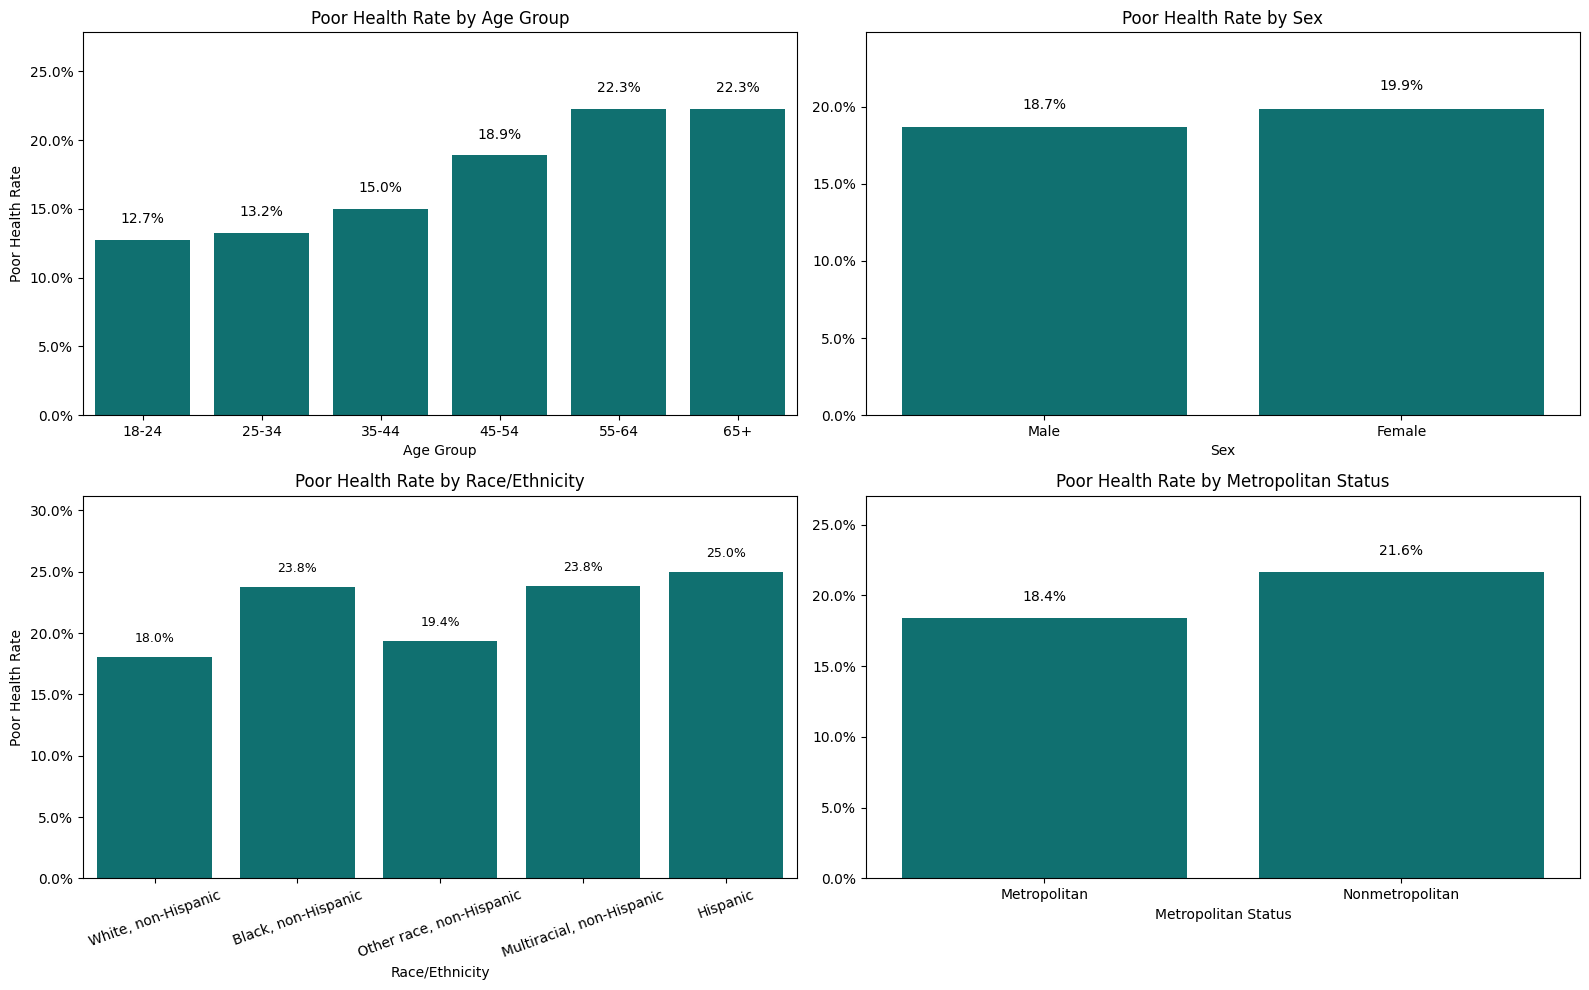

In [91]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

# 1. Age group vs poor health
age_order = ['18-24', '25-34', '35-44', '45-54', '55-64', '65+']
age_rate = (
    model_df.groupby('age_group')['poor_health']
    .mean()
    .reindex(age_order)
    .reset_index()
)
age_rate['poor_health'] = age_rate['poor_health'].astype(float)

sns.barplot(
    data=age_rate,
    x='age_group',
    y='poor_health',
    order=age_order,
    color='teal',
    ax=axes[0]
)
axes[0].set_title('Poor Health Rate by Age Group')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Poor Health Rate')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].set_ylim(0, age_rate['poor_health'].max() * 1.25)

for i, v in enumerate(age_rate['poor_health']):
    axes[0].text(i, v + 0.01, f'{v:.1%}', ha='center', va='bottom', fontsize=10)

# 2. Sex vs poor health
sex_order = [0, 1]
sex_rate = (
    model_df.groupby('is_female')['poor_health']
    .mean()
    .reindex(sex_order)
    .reset_index()
)
sex_rate['poor_health'] = sex_rate['poor_health'].astype(float)

sns.barplot(
    data=sex_rate,
    x='is_female',
    y='poor_health',
    order=sex_order,
    color='teal',
    ax=axes[1]
)
axes[1].set_title('Poor Health Rate by Sex')
axes[1].set_xlabel('Sex')
axes[1].set_ylabel('')
axes[1].set_xticklabels(['Male', 'Female'])
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].set_ylim(0, sex_rate['poor_health'].max() * 1.25)

for i, v in enumerate(sex_rate['poor_health']):
    axes[1].text(i, v + 0.01, f'{v:.1%}', ha='center', va='bottom', fontsize=10)

# 3. Race group vs poor health
race_order = [
    'White, non-Hispanic',
    'Black, non-Hispanic',
    'Other race, non-Hispanic',
    'Multiracial, non-Hispanic',
    'Hispanic'
]
race_rate = (
    model_df.groupby('race_group')['poor_health']
    .mean()
    .reindex(race_order)
    .reset_index()
)
race_rate['poor_health'] = race_rate['poor_health'].astype(float)

sns.barplot(
    data=race_rate,
    x='race_group',
    y='poor_health',
    order=race_order,
    color='teal',
    ax=axes[2]
)
axes[2].set_title('Poor Health Rate by Race/Ethnicity')
axes[2].set_xlabel('Race/Ethnicity')
axes[2].set_ylabel('Poor Health Rate')
axes[2].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[2].tick_params(axis='x', rotation=20)
axes[2].set_ylim(0, race_rate['poor_health'].max() * 1.25)

for i, v in enumerate(race_rate['poor_health']):
    axes[2].text(i, v + 0.01, f'{v:.1%}', ha='center', va='bottom', fontsize=9)

# 4. Urban status vs poor health
urban_order = [1, 0]
urban_rate = (
    model_df.groupby('is_urban')['poor_health']
    .mean()
    .reindex(urban_order)
    .reset_index()
)
urban_rate['poor_health'] = urban_rate['poor_health'].astype(float)

sns.barplot(
    data=urban_rate,
    x='is_urban',
    y='poor_health',
    order=urban_order,
    color='teal',
    ax=axes[3]
)
axes[3].set_title('Poor Health Rate by Metropolitan Status')
axes[3].set_xlabel('Metropolitan Status')
axes[3].set_ylabel('')
axes[3].set_xticklabels(['Metropolitan', 'Nonmetropolitan'])
axes[3].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[3].set_ylim(0, urban_rate['poor_health'].max() * 1.25)

for i, v in enumerate(urban_rate['poor_health']):
    axes[3].text(i, v + 0.01, f'{v:.1%}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

These demographic graphs show that poor health is not evenly distributed across population groups. Age has the clearest pattern, with poor health rates generally increasing across older age groups. Differences by sex are relatively small, while race/ethnicity and metropolitan status show more noticeable variation. Overall, these results provide useful background context for understanding how poor health is distributed across the sample.

### **Interaction Effects Between Key Variables**
After examining the independent relationships between poor health and each non-clinical factor, we next explore whether some variables work together in ways that reveal more complex patterns. This step moves beyond simple group-by-group comparisons and focuses on interaction effects, which helps us see whether the relationship between one variable and poor health changes depending on the level of another variable.

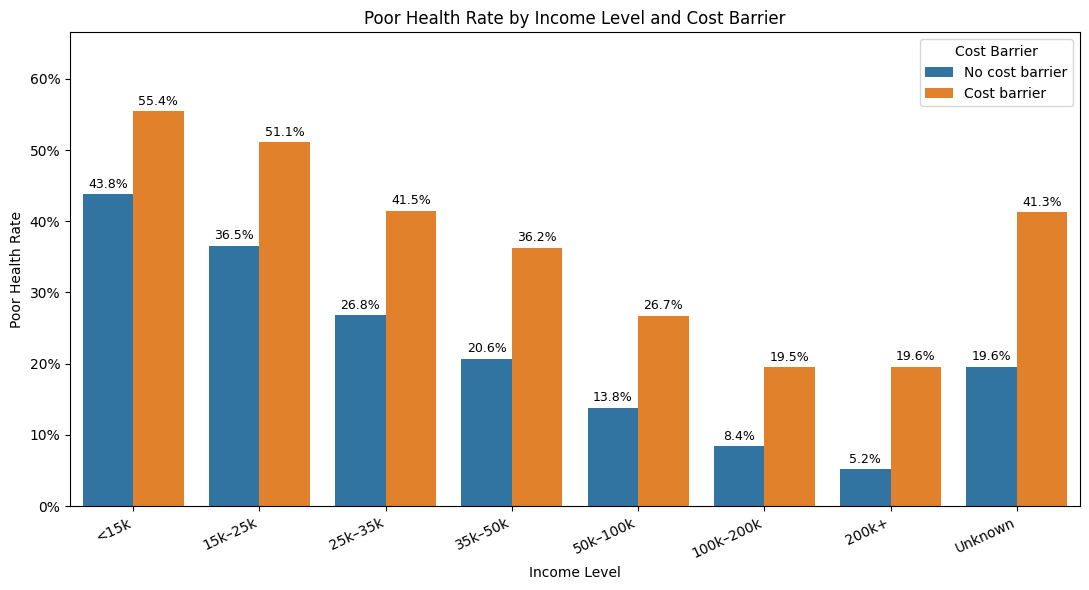

In [92]:
income_order = ['<15k', '15k-25k', '25k-35k', '35k-50k', '50k-100k', '100k-200k', '200k+', 'Unknown']

interaction_df = (
    model_df.groupby(['income_level', 'cost_barrier'])['poor_health']
    .mean()
    .reset_index()
)

interaction_df['income_level'] = pd.Categorical(
    interaction_df['income_level'],
    categories=income_order,
    ordered=True
)
interaction_df = interaction_df.sort_values('income_level')

plt.figure(figsize=(11, 6))
ax = sns.barplot(
    data=interaction_df,
    x='income_level',
    y='poor_health',
    hue='cost_barrier',
    order=income_order
)

ax.set_title('Poor Health Rate by Income Level and Cost Barrier')
ax.set_xlabel('Income Level')
ax.set_ylabel('Poor Health Rate')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylim(0, interaction_df['poor_health'].max() * 1.2)

# cleaner x-axis labels
ax.set_xticklabels(['<15k', '15k–25k', '25k–35k', '35k–50k', '50k–100k', '100k–200k', '200k+', 'Unknown'],
                   rotation=25, ha='right')

# fix legend labels
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['No cost barrier', 'Cost barrier'], title='Cost Barrier')

# add labels on bars
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.005,
            f'{height:.1%}',
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.tight_layout()
plt.show()

This graph shows a clear interaction between income level and cost barrier. Poor health rates are higher for respondents with a cost barrier in every income group, and the overall rate generally decreases as income rises. The gap is especially notable in lower-income groups, suggesting that cost-related barriers may have an even stronger impact among socioeconomically disadvantaged respondents. Overall, this pattern suggests that affordability and socioeconomic disadvantage may work together in shaping poor health risk.

### **Has_insurance VS cost barrier**

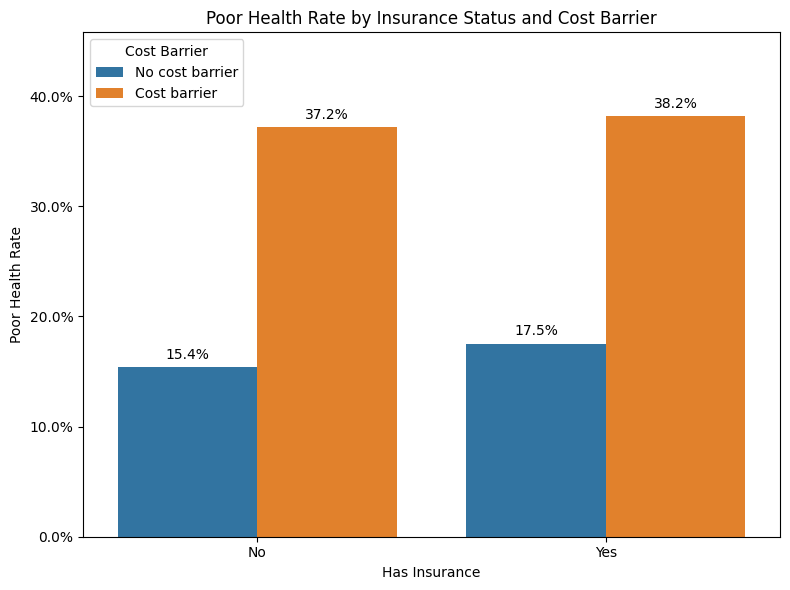

In [93]:
interaction_df = (
    model_df.groupby(['has_insurance', 'cost_barrier'])['poor_health']
    .mean()
    .reset_index()
)

interaction_df['has_insurance'] = pd.Categorical(
    interaction_df['has_insurance'],
    categories=[0, 1],
    ordered=True
)
interaction_df['cost_barrier'] = pd.Categorical(
    interaction_df['cost_barrier'],
    categories=[0, 1],
    ordered=True
)

interaction_df = interaction_df.sort_values(['has_insurance', 'cost_barrier'])

plt.figure(figsize=(8, 6))
ax = sns.barplot(
    data=interaction_df,
    x='has_insurance',
    y='poor_health',
    hue='cost_barrier'
)

ax.set_title('Poor Health Rate by Insurance Status and Cost Barrier')
ax.set_xlabel('Has Insurance')
ax.set_ylabel('Poor Health Rate')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xticklabels(['No', 'Yes'])
ax.set_ylim(0, interaction_df['poor_health'].max() * 1.2)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['No cost barrier', 'Cost barrier'], title='Cost Barrier')

for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.005,
            f'{height:.1%}',
            ha='center',
            va='bottom',
            fontsize=10
        )

plt.tight_layout()
plt.show()

This interaction plot compares poor health rates by insurance status within each cost barrier group. In both the insured and uninsured groups, respondents who reported a cost barrier had much higher poor health rates than those without a cost barrier. The difference between having and not having insurance is relatively small within each cost-barrier category, while the gap associated with cost barriers is much larger. This suggests that affordability of care may be a stronger descriptive signal of poor health than insurance coverage alone. In other words, having insurance does not fully reduce poor health risk if people still face cost-related barriers to care.

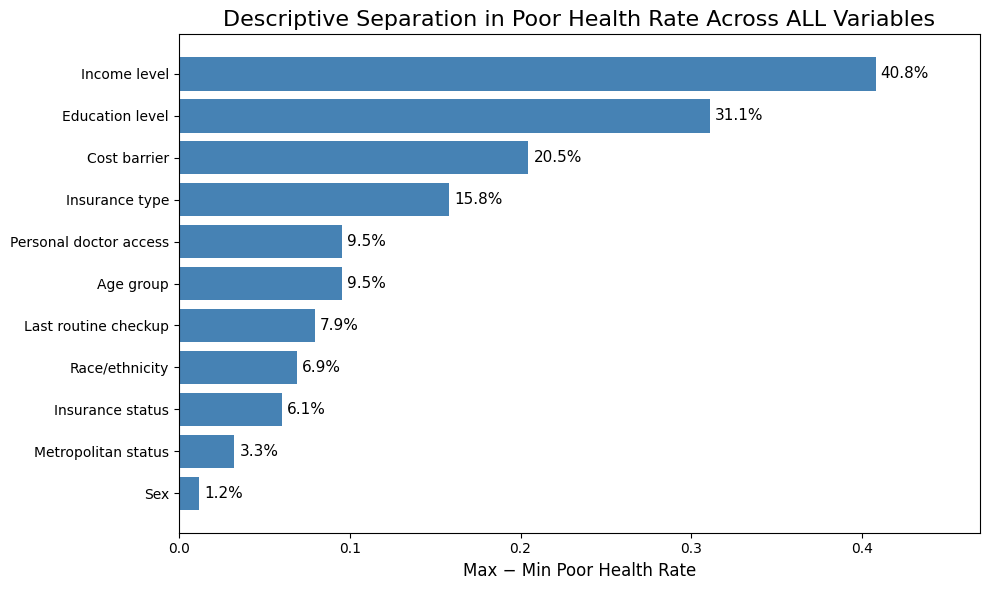

In [94]:
# function: compute descriptive separation for one variable
def get_separation(df, var, target='poor_health'):
    temp = df[[var, target]].dropna()
    rates = temp.groupby(var)[target].mean()
    return rates.max() - rates.min()

# variables to include in the full EDA summary
summary_vars = {
    'has_insurance': 'Insurance status',
    'insurance_type_grouped': 'Insurance type',
    'cost_barrier': 'Cost barrier',
    'has_personal_doctor': 'Personal doctor access',
    'last_checkup_time': 'Last routine checkup',
    'income_level': 'Income level',
    'education_level': 'Education level',
    'age_group': 'Age group',
    'is_female': 'Sex',
    'race_group': 'Race/ethnicity',
    'is_urban': 'Metropolitan status'
}

# compute separation values
separation_results = []
for var, label in summary_vars.items():
    sep = get_separation(model_df, var)
    separation_results.append({
        'Variable': label,
        'Separation': sep
    })

separation_df = pd.DataFrame(separation_results)
separation_df = separation_df.sort_values('Separation', ascending=True)

# plot
plt.figure(figsize=(10, 6))
bars = plt.barh(separation_df['Variable'], separation_df['Separation'], color='steelblue')

plt.title('Descriptive Separation in Poor Health Rate Across ALL Variables', fontsize=16)
plt.xlabel('Max − Min Poor Health Rate', fontsize=12)
plt.ylabel('')

# annotate
for bar, v in zip(bars, separation_df['Separation']):
    plt.text(
        v + 0.003,
        bar.get_y() + bar.get_height() / 2,
        f'{v:.1%}',
        va='center',
        fontsize=11
    )

plt.xlim(0, separation_df['Separation'].max() * 1.15)
plt.tight_layout()
plt.show()

This figure summarizes the descriptive separation in poor health rates across all major variables by showing the gap between the highest and lowest category within each variable. Income level shows the largest separation (40.8%), followed by education level (31.1%) and cost barrier (20.5%), suggesting that socioeconomic conditions and access-related barriers are strongly associated with poor health in the sample. Insurance type also shows a noticeable gap, while variables such as sex, metropolitan status, and race/ethnicity show smaller differences. Overall, this chart helps identify which variables appear to have the strongest descriptive relationship with poor health before moving to multivariable modeling.

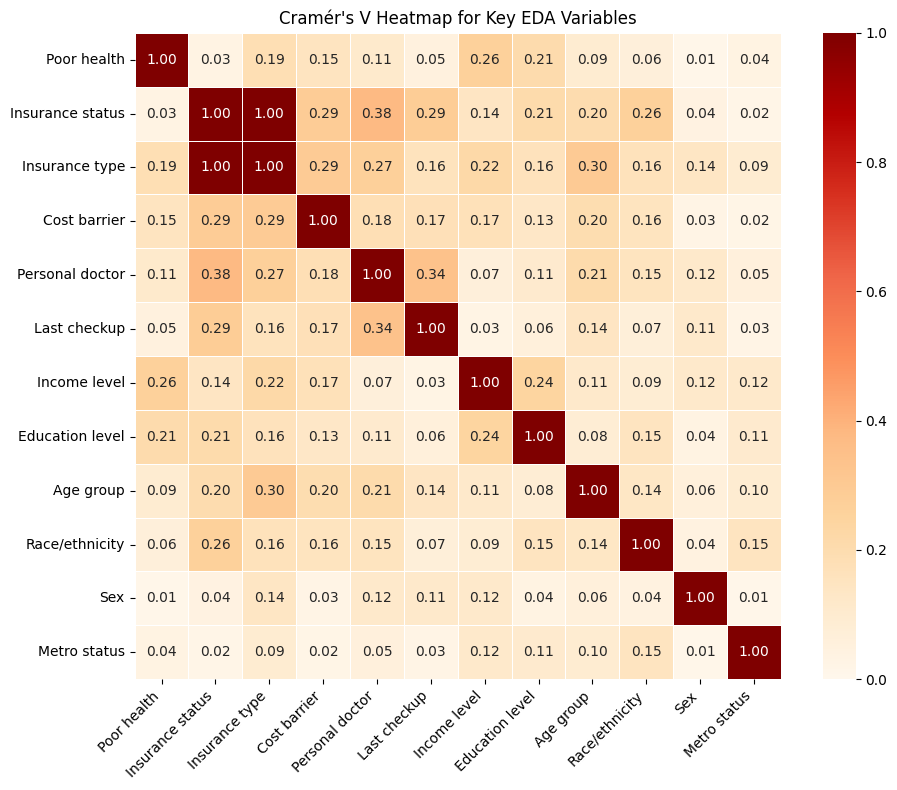

In [95]:
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
# Select categorical variables for the heatmap
heatmap_vars = [
    'poor_health',
    'has_insurance',
    'insurance_type_grouped',
    'cost_barrier',
    'has_personal_doctor',
    'last_checkup_time',
    'income_level',
    'education_level',
    'age_group',
    'race_group',
    'is_female',
    'is_urban'
]

heatmap_df = model_df[heatmap_vars].copy()

# Convert everything to string so categorical comparisons are consistent
for col in heatmap_df.columns:
    heatmap_df[col] = heatmap_df[col].astype(str)

# Function to compute Cramér's V
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape

    if n == 0:
        return np.nan

    phi2 = chi2 / n
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)

    if min((kcorr - 1), (rcorr - 1)) <= 0:
        return np.nan

    return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))

# Build Cramér's V matrix
cramers_matrix = pd.DataFrame(index=heatmap_vars, columns=heatmap_vars, dtype=float)

for col1 in heatmap_vars:
    for col2 in heatmap_vars:
        if col1 == col2:
            cramers_matrix.loc[col1, col2] = 1.0
        else:
            cramers_matrix.loc[col1, col2] = cramers_v(heatmap_df[col1], heatmap_df[col2])

# Rename labels for cleaner display
label_map = {
    'poor_health': 'Poor health',
    'has_insurance': 'Insurance status',
    'insurance_type_grouped': 'Insurance type',
    'cost_barrier': 'Cost barrier',
    'has_personal_doctor': 'Personal doctor',
    'last_checkup_time': 'Last checkup',
    'income_level': 'Income level',
    'education_level': 'Education level',
    'age_group': 'Age group',
    'race_group': 'Race/ethnicity',
    'is_female': 'Sex',
    'is_urban': 'Metro status'
}

cramers_matrix = cramers_matrix.rename(index=label_map, columns=label_map)

# Plot heatmap
plt.figure(figsize=(10, 8))
ax = sns.heatmap(
    cramers_matrix,
    annot=True,
    fmt='.2f',
    cmap='OrRd',
    vmin=0,
    vmax=1,
    square=True,
    linewidths=0.5
)

plt.title("Cramér's V Heatmap for Key EDA Variables")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

This heatmap summarizes the overall association strength among the main categorical variables in the EDA using Cramér’s V. In relation to poor health, income level (0.26) and education level (0.21) show relatively stronger associations than most other variables, which is consistent with the earlier bar charts and summary ranking results. Insurance type (0.19) and cost barrier (0.15) also show meaningful associations with poor health, while sex and metropolitan status are much weaker. The heatmap also shows that some predictors are related to each other, especially insurance status and insurance type, which is expected. Overall, this figure reinforces the main EDA finding that socioeconomic conditions and access-related barriers are more strongly associated with poor health than several background demographic variables.

## **Modeling Setup**

After completing the EDA, the next step is to define the final variable sets for predictive modeling. Instead of using one single feature set, we organize the predictors into layered models so that we can compare how insurance, healthcare access, socioeconomic conditions, and demographic context contribute to poor health prediction.

In [96]:
# Outcome variable
target = 'poor_health'

# Model 1: Insurance only
model1_vars = [
    'insurance_type_grouped'
]

# Model 2: Insurance + healthcare access
model2_vars = [
    'insurance_type_grouped',
    'cost_barrier',
    'has_personal_doctor',
    'last_checkup_time'
]

# Model 3: Insurance + healthcare access + SES
model3_vars = [
    'insurance_type_grouped',
    'cost_barrier',
    'has_personal_doctor',
    'last_checkup_time',
    'income_level',
    'education_level',
    'employment_status',
    'home_ownership'
]

# Model 4: Full non-clinical model
model4_vars = [
    'insurance_type_grouped',
    'cost_barrier',
    'has_personal_doctor',
    'last_checkup_time',
    'income_level',
    'education_level',
    'employment_status',
    'home_ownership',
    'age_group',
    'is_female',
    'race_group',
    'is_urban'
]

print("Model 1 variables:", model1_vars)
print("Model 2 variables:", model2_vars)
print("Model 3 variables:", model3_vars)
print("Model 4 variables:", model4_vars)

Model 1 variables: ['insurance_type_grouped']
Model 2 variables: ['insurance_type_grouped', 'cost_barrier', 'has_personal_doctor', 'last_checkup_time']
Model 3 variables: ['insurance_type_grouped', 'cost_barrier', 'has_personal_doctor', 'last_checkup_time', 'income_level', 'education_level', 'employment_status', 'home_ownership']
Model 4 variables: ['insurance_type_grouped', 'cost_barrier', 'has_personal_doctor', 'last_checkup_time', 'income_level', 'education_level', 'employment_status', 'home_ownership', 'age_group', 'is_female', 'race_group', 'is_urban']


### **Variable Types for Modeling**

Before building the models, we organize the predictors by variable type. Since the final feature set is composed mainly of binary and categorical variables, this step helps us prepare a consistent preprocessing strategy for the later machine learning models.

In [97]:
# Binary variables
binary_vars = [
    'cost_barrier',
    'is_female',
    'is_urban'
]

# Categorical variables
categorical_vars = [
    'insurance_type_grouped',
    'has_personal_doctor',
    'last_checkup_time',
    'income_level',
    'education_level',
    'employment_status',
    'home_ownership',
    'age_group',
    'race_group'
]

print("Binary variables:", binary_vars)
print("Categorical variables:", categorical_vars)

Binary variables: ['cost_barrier', 'is_female', 'is_urban']
Categorical variables: ['insurance_type_grouped', 'has_personal_doctor', 'last_checkup_time', 'income_level', 'education_level', 'employment_status', 'home_ownership', 'age_group', 'race_group']


## **Feature Engineering**

In [98]:
# Target variable
y = model_df[target].copy()

# Feature sets for each model
X1 = model_df[model1_vars].copy()
X2 = model_df[model2_vars].copy()
X3 = model_df[model3_vars].copy()
X4 = model_df[model4_vars].copy()

# Quick shape checks
print("Shape of y:", y.shape)
print("Shape of X1:", X1.shape)
print("Shape of X2:", X2.shape)
print("Shape of X3:", X3.shape)
print("Shape of X4:", X4.shape)

print("\nModel 1 features:", X1.columns.tolist())
print("\nModel 2 features:", X2.columns.tolist())
print("\nModel 3 features:", X3.columns.tolist())
print("\nModel 4 features:", X4.columns.tolist())

Shape of y: (399765,)
Shape of X1: (399765, 1)
Shape of X2: (399765, 4)
Shape of X3: (399765, 8)
Shape of X4: (399765, 12)

Model 1 features: ['insurance_type_grouped']

Model 2 features: ['insurance_type_grouped', 'cost_barrier', 'has_personal_doctor', 'last_checkup_time']

Model 3 features: ['insurance_type_grouped', 'cost_barrier', 'has_personal_doctor', 'last_checkup_time', 'income_level', 'education_level', 'employment_status', 'home_ownership']

Model 4 features: ['insurance_type_grouped', 'cost_barrier', 'has_personal_doctor', 'last_checkup_time', 'income_level', 'education_level', 'employment_status', 'home_ownership', 'age_group', 'is_female', 'race_group', 'is_urban']


#### **Train and Test Split**

In [99]:
indices = np.arange(len(model_df))

train_idx, test_idx = train_test_split(
    indices,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Apply the same split to all model feature sets
X1_train, X1_test = X1.iloc[train_idx].copy(), X1.iloc[test_idx].copy()
X2_train, X2_test = X2.iloc[train_idx].copy(), X2.iloc[test_idx].copy()
X3_train, X3_test = X3.iloc[train_idx].copy(), X3.iloc[test_idx].copy()
X4_train, X4_test = X4.iloc[train_idx].copy(), X4.iloc[test_idx].copy()

# Shared target split
y_train, y_test = y.iloc[train_idx].copy(), y.iloc[test_idx].copy()

print("\nTrain target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True))


Train target distribution:
poor_health
0    0.806893
1    0.193107
Name: proportion, dtype: Float64

Test target distribution:
poor_health
0    0.806899
1    0.193101
Name: proportion, dtype: Float64


### **Class Imbalance Handling**

Because poor health is the minority class in this dataset, we explicitly account for class imbalance during model training. Logistic Regression and Random Forest use balanced class weights, while XGBoost uses a scale_pos_weight value based on the ratio of negative to positive cases.

In [100]:
# Class imbalance summary
n_negative = (y_train == 0).sum()
n_positive = (y_train == 1).sum()
scale_pos_weight = n_negative / n_positive

print("Negative cases:", n_negative)
print("Positive cases:", n_positive)
print("scale_pos_weight:", scale_pos_weight)

Negative cases: 258054
Positive cases: 61758
scale_pos_weight: 4.178470805401729


### **Preprocessing and Modeling Pipelines**

In this step, we prepare a consistent preprocessing strategy for the four layered models. We use the variable types defined earlier, apply one-hot encoding to categorical variables, and pass binary variables through directly. This allows us to compare Logistic Regression, Random Forest, and XGBoost under the same feature setup.

In [101]:
# Helper function: keep only the variables that appear in each model
def split_vars_by_model(model_vars):
    model_binary = [v for v in binary_vars if v in model_vars]
    model_categorical = [v for v in categorical_vars if v in model_vars]
    return model_binary, model_categorical

model1_binary, model1_categorical = split_vars_by_model(model1_vars)
model2_binary, model2_categorical = split_vars_by_model(model2_vars)
model3_binary, model3_categorical = split_vars_by_model(model3_vars)
model4_binary, model4_categorical = split_vars_by_model(model4_vars)

In [102]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor1 = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), model1_categorical),
        ('bin', 'passthrough', model1_binary)
    ]
)

preprocessor2 = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), model2_categorical),
        ('bin', 'passthrough', model2_binary)
    ]
)

preprocessor3 = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), model3_categorical),
        ('bin', 'passthrough', model3_binary)
    ]
)

preprocessor4 = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), model4_categorical),
        ('bin', 'passthrough', model4_binary)
    ]
)

## **Modeling**

#### **Model Pipline Setup**


In [103]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

lr_model = LogisticRegression(
    max_iter=2000,
    random_state=42,
    class_weight='balanced'
)

rf_model = RandomForestClassifier(
    n_estimators=50,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

xgb_model = XGBClassifier(
    n_estimators=50,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42,
    scale_pos_weight=scale_pos_weight
)

In [104]:
# Logistic Regression pipelines
lr_pipe1 = Pipeline([('preprocessor', preprocessor1), ('model', lr_model)])
lr_pipe2 = Pipeline([('preprocessor', preprocessor2), ('model', lr_model)])
lr_pipe3 = Pipeline([('preprocessor', preprocessor3), ('model', lr_model)])
lr_pipe4 = Pipeline([('preprocessor', preprocessor4), ('model', lr_model)])

# Random Forest pipelines
rf_pipe1 = Pipeline([('preprocessor', preprocessor1), ('model', rf_model)])
rf_pipe2 = Pipeline([('preprocessor', preprocessor2), ('model', rf_model)])
rf_pipe3 = Pipeline([('preprocessor', preprocessor3), ('model', rf_model)])
rf_pipe4 = Pipeline([('preprocessor', preprocessor4), ('model', rf_model)])

# XGBoost pipelines
xgb_pipe1 = Pipeline([('preprocessor', preprocessor1), ('model', xgb_model)])
xgb_pipe2 = Pipeline([('preprocessor', preprocessor2), ('model', xgb_model)])
xgb_pipe3 = Pipeline([('preprocessor', preprocessor3), ('model', xgb_model)])
xgb_pipe4 = Pipeline([('preprocessor', preprocessor4), ('model', xgb_model)])

### **Cross-Validation**
Before evaluating the models on the test set, we use cross-validation on the training data to obtain more stable performance estimates. This helps us compare the layered models and algorithms more reliably before moving to final test evaluation.

In [105]:
from sklearn.model_selection import cross_validate, StratifiedKFold

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

def run_cv(model_name, pipeline, X_train, y_train):
    cv_results = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )

    summary = {
        'model': model_name,
        'cv_accuracy': cv_results['test_accuracy'].mean(),
        'cv_precision': cv_results['test_precision'].mean(),
        'cv_recall': cv_results['test_recall'].mean(),
        'cv_f1': cv_results['test_f1'].mean(),
        'cv_roc_auc': cv_results['test_roc_auc'].mean()
    }

    return summary

### **Logistic Regression: Cross-Validation Results**

We first evaluate Logistic Regression across the four layered models using cross-validation on the training data. This provides a baseline view of how predictive performance changes as we add healthcare access, socioeconomic, and demographic information.

In [106]:
lr_cv_results = []

lr_cv_results.append(run_cv("LR_Model1", lr_pipe1, X1_train, y_train))
lr_cv_results.append(run_cv("LR_Model2", lr_pipe2, X2_train, y_train))
lr_cv_results.append(run_cv("LR_Model3", lr_pipe3, X3_train, y_train))
lr_cv_results.append(run_cv("LR_Model4", lr_pipe4, X4_train, y_train))

lr_cv_results_df = pd.DataFrame(lr_cv_results)
lr_cv_results_df = lr_cv_results_df.sort_values(
    by=['cv_recall', 'cv_roc_auc'],
    ascending=False
).reset_index(drop=True)

lr_cv_results_df

,model,cv_accuracy,cv_precision,cv_recall,cv_f1,cv_roc_auc
0,LR_Model1,0.539523,0.258869,0.743207,0.383989,0.618498
1,LR_Model2,0.569947,0.272962,0.737605,0.398464,0.684420
2,LR_Model4,0.718475,0.372040,0.665533,0.477274,0.767204
3,LR_Model3,0.711965,0.364707,0.662570,0.470454,0.763160


### **Random Forest: Cross-Validation Results**

Next, we evaluate Random Forest across the same four layered models. This helps us compare whether a tree-based model captures the non-clinical predictors more effectively than Logistic Regression.

In [107]:
rf_cv_results = []

rf_cv_results.append(run_cv("RF_Model1", rf_pipe1, X1_train, y_train))
rf_cv_results.append(run_cv("RF_Model2", rf_pipe2, X2_train, y_train))
rf_cv_results.append(run_cv("RF_Model3", rf_pipe3, X3_train, y_train))
rf_cv_results.append(run_cv("RF_Model4", rf_pipe4, X4_train, y_train))

rf_cv_results_df = pd.DataFrame(rf_cv_results)
rf_cv_results_df = rf_cv_results_df.sort_values(
    by=['cv_recall', 'cv_roc_auc'],
    ascending=False
).reset_index(drop=True)

rf_cv_results_df

,model,cv_accuracy,cv_precision,cv_recall,cv_f1,cv_roc_auc
0,RF_Model2,0.564222,0.272066,0.749992,0.399286,0.684916
1,RF_Model1,0.539523,0.258869,0.743207,0.383989,0.618498
2,RF_Model3,0.730076,0.371389,0.574225,0.451040,0.723365
3,RF_Model4,0.747696,0.373795,0.453982,0.410000,0.690252


### **XGBoost: Cross-Validation Results**

Finally, we evaluate XGBoost across the four layered models using cross-validation on the training data. Since XGBoost is often strong in predictive tasks, this step helps us assess whether it provides better discrimination and recall than Logistic Regression and Random Forest.

In [108]:
xgb_cv_results = []

xgb_cv_results.append(run_cv("XGB_Model1", xgb_pipe1, X1_train, y_train))
xgb_cv_results.append(run_cv("XGB_Model2", xgb_pipe2, X2_train, y_train))
xgb_cv_results.append(run_cv("XGB_Model3", xgb_pipe3, X3_train, y_train))
xgb_cv_results.append(run_cv("XGB_Model4", xgb_pipe4, X4_train, y_train))

xgb_cv_results_df = pd.DataFrame(xgb_cv_results)
xgb_cv_results_df = xgb_cv_results_df.sort_values(
    by=['cv_recall', 'cv_roc_auc'],
    ascending=False
).reset_index(drop=True)

xgb_cv_results_df

,model,cv_accuracy,cv_precision,cv_recall,cv_f1,cv_roc_auc
0,XGB_Model1,0.539523,0.258869,0.743207,0.383989,0.618498
1,XGB_Model2,0.568009,0.272866,0.743062,0.399154,0.684898
2,XGB_Model3,0.705571,0.359061,0.668351,0.467142,0.761644
3,XGB_Model4,0.709654,0.363014,0.667088,0.470164,0.763995


### **Cross-Validation Summary**

The updated cross-validation results show a clearer and more realistic pattern after handling class imbalance during training. Insurance type alone still provides only limited balanced predictive value: although Model 1 now shows high recall, this comes at the cost of very low accuracy and precision, indicating that the model is too aggressive and not well balanced. Adding healthcare access variables in Model 2 produces only modest improvement and still does not provide a strong overall tradeoff.

The most meaningful improvement occurs when SES variables are added in Model 3. Across Logistic Regression, Random Forest, and XGBoost, Model 3 produces much stronger F1 scores and ROC-AUC values while maintaining substantially higher recall than before, suggesting that socioeconomic variables add major predictive value beyond insurance and healthcare access alone. This result remains highly consistent with the EDA findings.

Adding demographic variables in Model 4 leads to only modest additional improvement over Model 3. In most cases, the gain is small, suggesting that demographic context contributes less incremental predictive value than SES. Across algorithms, Logistic Regression and XGBoost appear to provide the most balanced performance overall, while Random Forest is somewhat less stable under the full model. Overall, these results suggest that SES variables remain the most important source of predictive improvement in the layered modeling framework, while insurance information alone is not sufficient for identifying poor health risk.

### **Final Test-Set Evaluation for the Full Non-Clinical Model**

After comparing the layered models through cross-validation, we now evaluate the full non-clinical model (Model 4) on the held-out test set. Using the same final feature set for Logistic Regression, Random Forest, and XGBoost allows us to compare the three algorithms more directly under the same information conditions.

In [109]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

def evaluate_test_model(model_name, fitted_pipeline, X_test, y_test):
    y_pred = fitted_pipeline.predict(X_test)
    y_prob = fitted_pipeline.predict_proba(X_test)[:, 1]

    return {
        'model': model_name,
        'test_accuracy': accuracy_score(y_test, y_pred),
        'test_precision': precision_score(y_test, y_pred, zero_division=0),
        'test_recall': recall_score(y_test, y_pred, zero_division=0),
        'test_f1': f1_score(y_test, y_pred, zero_division=0),
        'test_roc_auc': roc_auc_score(y_test, y_prob)
    }

In [110]:
# Fit Model 4 for each algorithm
lr_pipe4.fit(X4_train, y_train)
rf_pipe4.fit(X4_train, y_train)
xgb_pipe4.fit(X4_train, y_train)

# Evaluate on test set
test_results = []
test_results.append(evaluate_test_model("LR_Model4", lr_pipe4, X4_test, y_test))
test_results.append(evaluate_test_model("RF_Model4", rf_pipe4, X4_test, y_test))
test_results.append(evaluate_test_model("XGB_Model4", xgb_pipe4, X4_test, y_test))

test_results_df = pd.DataFrame(test_results)
test_results_df = test_results_df.sort_values(
    by=['test_recall', 'test_roc_auc'],
    ascending=False
).reset_index(drop=True)

test_results_df

,model,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
0,XGB_Model4,0.711093,0.365595,0.674785,0.474246,0.764821
1,LR_Model4,0.719273,0.373410,0.669279,0.479367,0.767485
2,RF_Model4,0.744037,0.372734,0.476715,0.418360,0.692739


### **Confusion Matrices for the Full Non-Clinical Model**

To better understand how the three final models behave under the default classification threshold, we next examine their confusion matrices on the test set. This allows us to compare how many poor health cases each model correctly identifies and how many are still missed, while also showing the tradeoff between sensitivity and false positives.

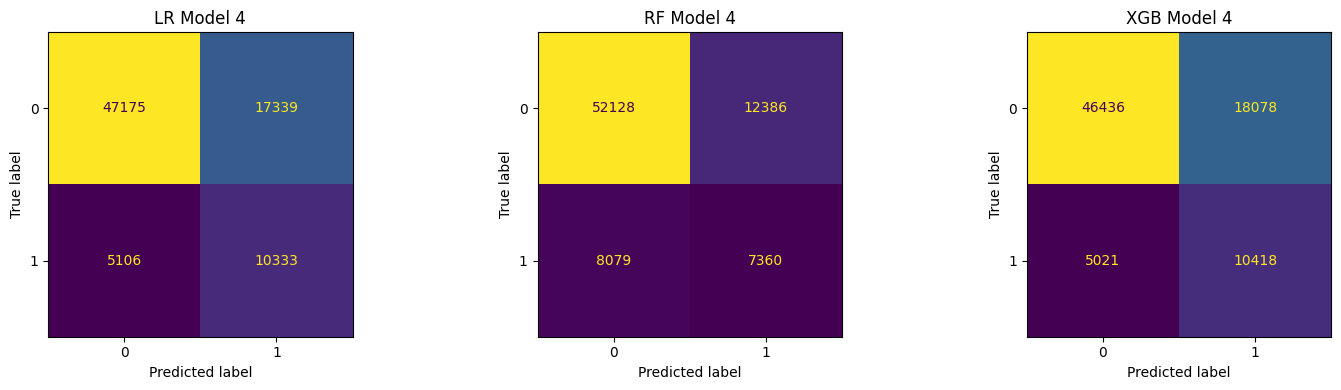

In [111]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Predictions on test set
lr_pred = lr_pipe4.predict(X4_test)
rf_pred = rf_pipe4.predict(X4_test)
xgb_pred = xgb_pipe4.predict(X4_test)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, lr_pred)
).plot(ax=axes[0], colorbar=False, values_format='d')
axes[0].set_title("LR Model 4")

ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, rf_pred)
).plot(ax=axes[1], colorbar=False, values_format='d')
axes[1].set_title("RF Model 4")

ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, xgb_pred)
).plot(ax=axes[2], colorbar=False, values_format='d')
axes[2].set_title("XGB Model 4")

plt.tight_layout()
plt.show()

The confusion matrices show clear differences in how the three models classify poor health cases. Logistic Regression correctly identifies 10,333 poor health cases and XGBoost correctly identifies 10,418, while Random Forest identifies only 7,360. This explains why Logistic Regression and XGBoost have much higher recall than Random Forest. However, this stronger sensitivity also comes with more false positives: Logistic Regression produces 17,339 false positives and XGBoost produces 18,078, compared with 12,386 for Random Forest. In contrast, Random Forest is more conservative, with fewer false positives but substantially more missed poor health cases (8,079 false negatives, compared with 5,106 for Logistic Regression and 5,021 for XGBoost). Overall, the figure shows that Logistic Regression and XGBoost are better at identifying poor health risk, while Random Forest is less sensitive under the default threshold.

### **Logistic Regression**
We next examine Logistic Regression separately to better understand why it performs strongly in the full non-clinical model and which predictors contribute most to its classification decisions.

In [112]:
# Get feature names after preprocessing
feature_names = lr_pipe4.named_steps['preprocessor'].get_feature_names_out()

# Get coefficients from Logistic Regression
coefficients = lr_pipe4.named_steps['model'].coef_[0]

lr_coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients,
    'odds_ratio': np.exp(coefficients)
})

# Sort by absolute effect size
lr_coef_df['abs_coefficient'] = lr_coef_df['coefficient'].abs()
lr_coef_df = lr_coef_df.sort_values('abs_coefficient', ascending=False)

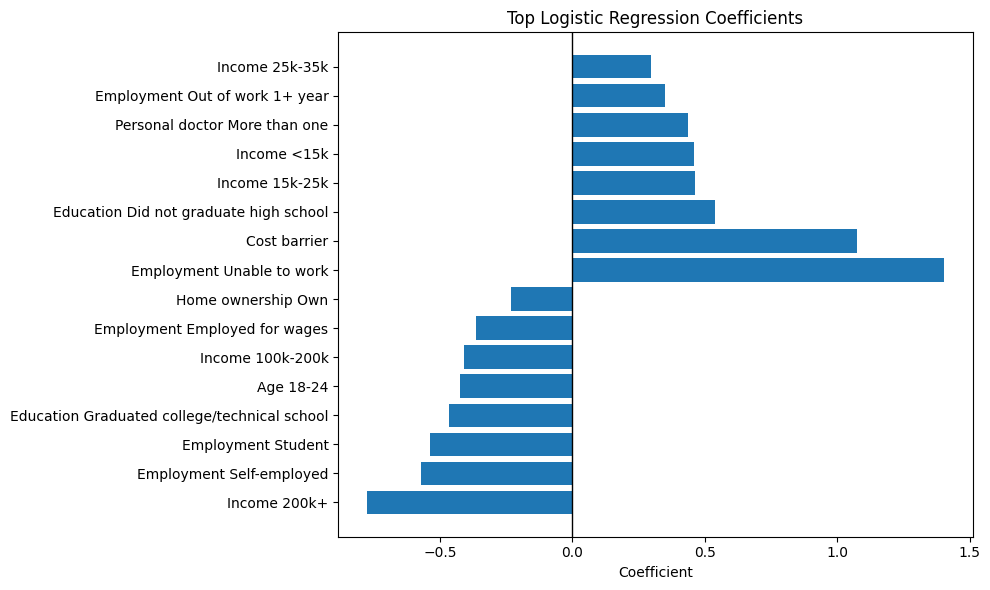

In [113]:

top_positive = lr_coef_df.sort_values('coefficient', ascending=False).head(8)
top_negative = lr_coef_df.sort_values('coefficient', ascending=True).head(8)
plot_df = pd.concat([top_negative, top_positive]).copy()


def clean_feature_name(name):
    name = name.replace('cat__', '')
    name = name.replace('bin__', '')
    name = name.replace('income_level', 'Income')
    name = name.replace('education_level', 'Education')
    name = name.replace('employment_status', 'Employment')
    name = name.replace('home_ownership', 'Home ownership')
    name = name.replace('has_personal_doctor', 'Personal doctor')
    name = name.replace('age_group', 'Age')
    name = name.replace('race_group', 'Race')
    name = name.replace('insurance_type_grouped', 'Insurance type')
    name = name.replace('cost_barrier', 'Cost barrier')
    name = name.replace('_', ' ')
    return name

plot_df['feature_clean'] = plot_df['feature'].apply(clean_feature_name)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(plot_df['feature_clean'], plot_df['coefficient'])
plt.axvline(0, color='black', linewidth=1)
plt.title('Top Logistic Regression Coefficients')
plt.xlabel('Coefficient')
plt.ylabel('')
plt.tight_layout()
plt.show()

The coefficient plot suggests that both socioeconomic and healthcare access variables contribute meaningfully to the Logistic Regression model. Categories such as being unable to work, having a cost barrier, lower income, and lower education are associated with higher predicted odds of poor health, while higher income, higher education, and more stable employment categories are associated with lower predicted odds. These patterns are generally consistent with the earlier EDA results and help explain why the full model performs better than the earlier model layers.

### **Random Forest**
We next examine Random Forest separately to understand which predictors contribute most to the final full model and how its classification behavior differs from the other algorithms.

#### **Random Forest Feature Importance**

To better understand which variables contribute most to the Random Forest model, we next examine feature importance scores from the full non-clinical model. This helps identify which predictors are most influential in the model’s classification decisions.

In [114]:
rf_feature_names = rf_pipe4.named_steps['preprocessor'].get_feature_names_out()
rf_importances = rf_pipe4.named_steps['model'].feature_importances_

rf_importance_df = pd.DataFrame({
    'feature': rf_feature_names,
    'importance': rf_importances
})

rf_importance_df = rf_importance_df.sort_values('importance', ascending=False)

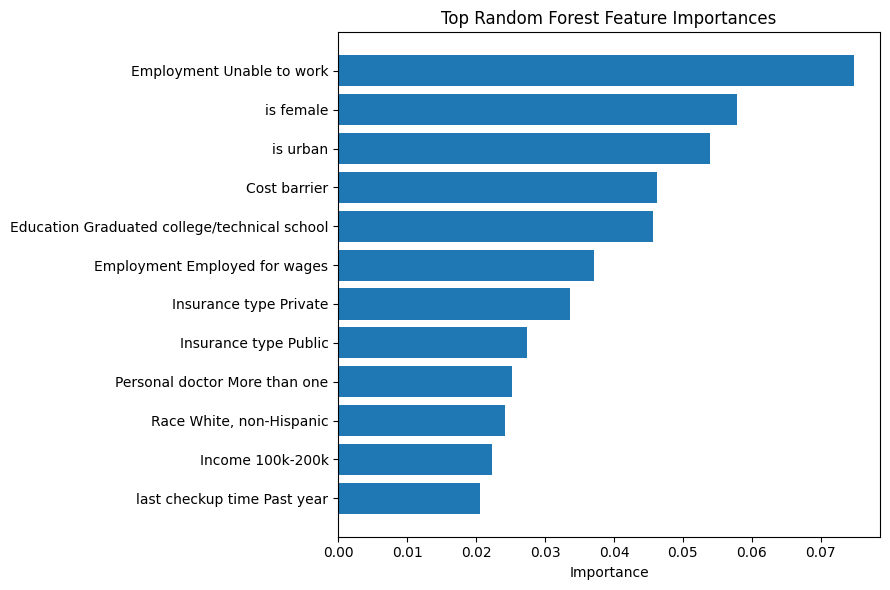

In [115]:
top_rf = rf_importance_df.head(12).copy()

def clean_feature_name(name):
    name = name.replace('cat__', '')
    name = name.replace('bin__', '')
    name = name.replace('income_level', 'Income')
    name = name.replace('education_level', 'Education')
    name = name.replace('employment_status', 'Employment')
    name = name.replace('home_ownership', 'Home ownership')
    name = name.replace('has_personal_doctor', 'Personal doctor')
    name = name.replace('age_group', 'Age')
    name = name.replace('race_group', 'Race')
    name = name.replace('insurance_type_grouped', 'Insurance type')
    name = name.replace('cost_barrier', 'Cost barrier')
    name = name.replace('_', ' ')
    return name

top_rf['feature_clean'] = top_rf['feature'].apply(clean_feature_name)
top_rf = top_rf.sort_values('importance', ascending=True)

plt.figure(figsize=(9, 6))
plt.barh(top_rf['feature_clean'], top_rf['importance'])
plt.title('Top Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('')
plt.tight_layout()
plt.show()

The Random Forest feature importance plot shows that Employment: Unable to work is the strongest predictor by a clear margin. Other highly ranked features include is_female, is_urban, and Cost barrier, followed by variables related to education, insurance type, income, age, and personal doctor access. This suggests that the model is using a broad combination of socioeconomic, access-related, and demographic variables rather than depending on insurance information alone.

### **XGBoost**
Finally, we examine XGBoost separately to identify which predictors contribute most strongly to the final full model and to compare its interpretation with the other algorithms.

#### **XGBoost Feature Importance**

We next examine feature importance for the XGBoost full model to identify which variables contribute most strongly to its predictions.

In [116]:
xgb_feature_names = xgb_pipe4.named_steps['preprocessor'].get_feature_names_out()
xgb_importances = xgb_pipe4.named_steps['model'].feature_importances_

xgb_importance_df = pd.DataFrame({
    'feature': xgb_feature_names,
    'importance': xgb_importances
})

xgb_importance_df = xgb_importance_df.sort_values('importance', ascending=False)

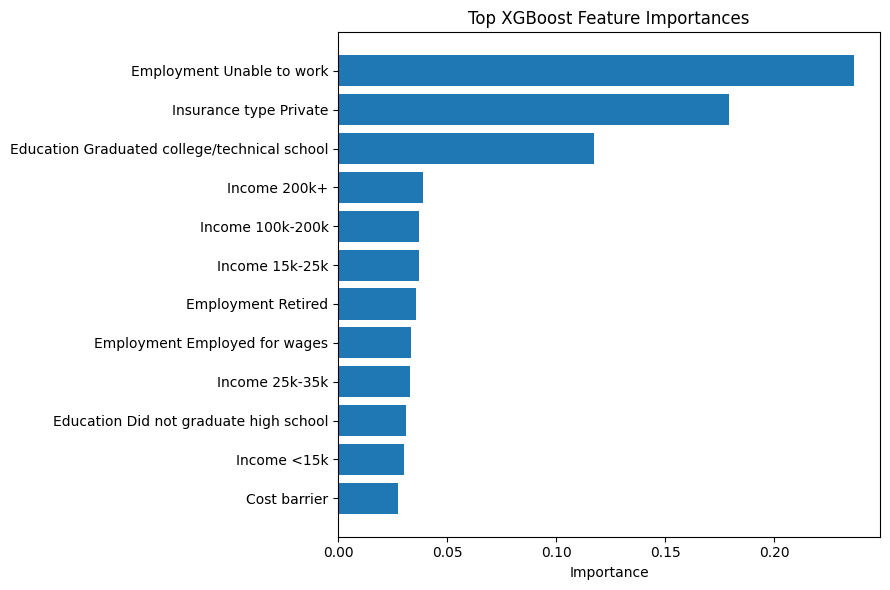

In [117]:
top_xgb = xgb_importance_df.head(12).copy()

def clean_feature_name(name):
    name = name.replace('cat__', '')
    name = name.replace('bin__', '')
    name = name.replace('income_level', 'Income')
    name = name.replace('education_level', 'Education')
    name = name.replace('employment_status', 'Employment')
    name = name.replace('home_ownership', 'Home ownership')
    name = name.replace('has_personal_doctor', 'Personal doctor')
    name = name.replace('age_group', 'Age')
    name = name.replace('race_group', 'Race')
    name = name.replace('insurance_type_grouped', 'Insurance type')
    name = name.replace('cost_barrier', 'Cost barrier')
    name = name.replace('_', ' ')
    return name

top_xgb['feature_clean'] = top_xgb['feature'].apply(clean_feature_name)
top_xgb = top_xgb.sort_values('importance', ascending=True)

plt.figure(figsize=(9, 6))
plt.barh(top_xgb['feature_clean'], top_xgb['importance'])
plt.title('Top XGBoost Feature Importances')
plt.xlabel('Importance')
plt.ylabel('')
plt.tight_layout()
plt.show()

The XGBoost feature importance plot shows that Employment: Unable to work is the most influential predictor by a clear margin. Insurance type: Private and Education: Graduated college/technical school also stand out, followed by several income categories and employment-related variables. Compared with Random Forest, XGBoost appears to concentrate more of its predictive power in a smaller set of key features.

## **Comparative Evaluation of Final Models**
After interpreting Logistic Regression, Random Forest, and XGBoost separately, we next compare the three final models directly. This section shifts from model-specific interpretation to cross-model evaluation, allowing us to assess which final non-clinical model performs best overall and how the models differ in their tradeoff between discrimination, precision, and recall.

### **Precision–Recall Curve Comparison on the Test Set**

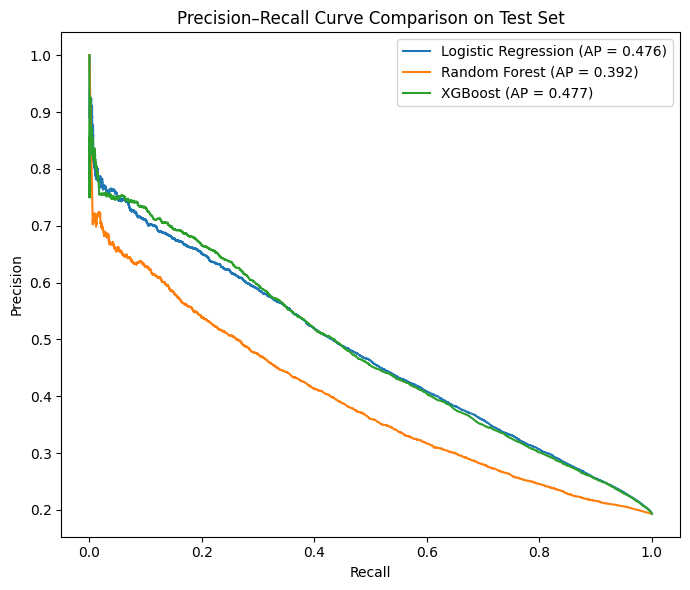

In [118]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Predicted probabilities
lr_prob = lr_pipe4.predict_proba(X4_test)[:, 1]
rf_prob = rf_pipe4.predict_proba(X4_test)[:, 1]
xgb_prob = xgb_pipe4.predict_proba(X4_test)[:, 1]

# Precision-recall values
lr_precision, lr_recall, _ = precision_recall_curve(y_test, lr_prob)
rf_precision, rf_recall, _ = precision_recall_curve(y_test, rf_prob)
xgb_precision, xgb_recall, _ = precision_recall_curve(y_test, xgb_prob)

# Average precision
lr_ap = average_precision_score(y_test, lr_prob)
rf_ap = average_precision_score(y_test, rf_prob)
xgb_ap = average_precision_score(y_test, xgb_prob)

plt.figure(figsize=(7, 6))
plt.plot(lr_recall, lr_precision, label=f'Logistic Regression (AP = {lr_ap:.3f})')
plt.plot(rf_recall, rf_precision, label=f'Random Forest (AP = {rf_ap:.3f})')
plt.plot(xgb_recall, xgb_precision, label=f'XGBoost (AP = {xgb_ap:.3f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision–Recall Curve Comparison on Test Set')
plt.legend()
plt.tight_layout()
plt.show()

The Precision–Recall curves show that Logistic Regression and XGBoost perform very similarly and both consistently outperform Random Forest across most recall levels. This pattern is also reflected in the average precision scores, where Logistic Regression (AP = 0.476) and XGBoost (AP = 0.477) are nearly identical and both higher than Random Forest (AP = 0.392). Overall, the figure suggests that Logistic Regression and XGBoost provide stronger precision–recall performance for identifying poor health risk, while Random Forest is less competitive under the full non-clinical model.

### **ROC Curve Comparison on the Test Set**

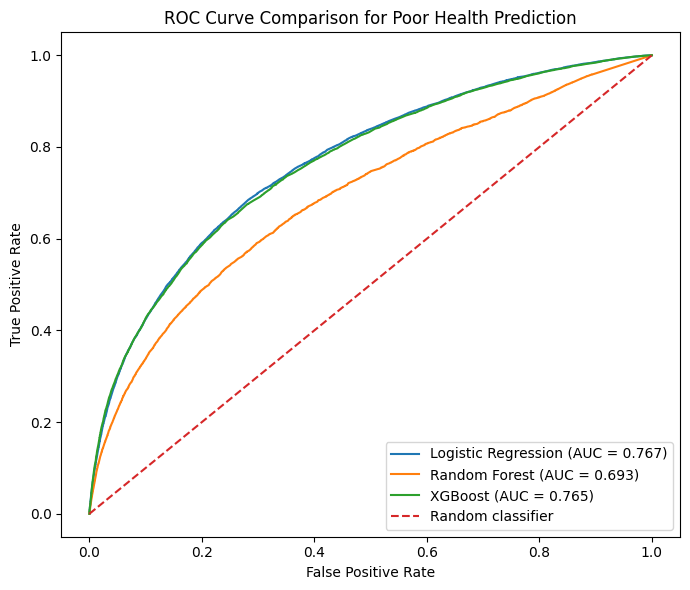

In [120]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

lr_prob = lr_pipe4.predict_proba(X4_test)[:, 1]
rf_prob = rf_pipe4.predict_proba(X4_test)[:, 1]
xgb_prob = xgb_pipe4.predict_proba(X4_test)[:, 1]

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_prob)

lr_roc_auc = auc(lr_fpr, lr_tpr)
rf_roc_auc = auc(rf_fpr, rf_tpr)
xgb_roc_auc = auc(xgb_fpr, xgb_tpr)

plt.figure(figsize=(7, 6))
plt.plot(lr_fpr, lr_tpr, label=f'Logistic Regression (AUC = {lr_roc_auc:.3f})')
plt.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {rf_roc_auc:.3f})')
plt.plot(xgb_fpr, xgb_tpr, label=f'XGBoost (AUC = {xgb_roc_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison for Poor Health Prediction')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

The ROC curves show that Logistic Regression and XGBoost perform almost identically across most of the false-positive range, and both stay clearly above Random Forest. Logistic Regression has the highest ROC-AUC at 0.767, but the gap from XGBoost is very small (0.765), so in practice these two models have nearly the same overall discrimination ability. In contrast, the Random Forest curve stays consistently lower, especially through the middle range of false positive rates, which explains its noticeably lower ROC-AUC of 0.693. This means that when the goal is to separate higher-risk from lower-risk respondents using the full non-clinical model, Logistic Regression and XGBoost are both much stronger than Random Forest, while Logistic Regression holds only a slight overall advantage over XGBoost.

### **Incremental Performance Gains Across Layered Models**

To directly connect the modeling results back to the research questions, we compare performance from Model 1 to Model 4 across the three algorithms. This layered comparison shows how much predictive value is added when healthcare access, socioeconomic status, and demographic variables are introduced beyond insurance-related information alone. We focus on ROC-AUC and F1 score because they provide a clearer summary of overall model quality than recall alone.

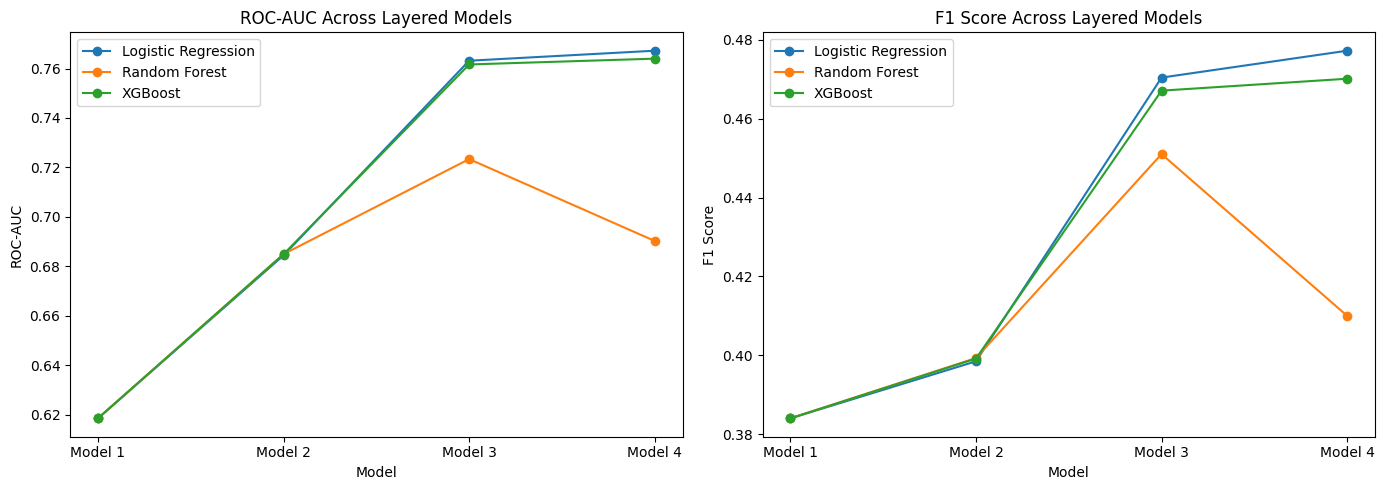

In [121]:
lr_plot = lr_cv_results_df.copy()
rf_plot = rf_cv_results_df.copy()
xgb_plot = xgb_cv_results_df.copy()

lr_plot["algorithm"] = "Logistic Regression"
rf_plot["algorithm"] = "Random Forest"
xgb_plot["algorithm"] = "XGBoost"

cv_plot_df = pd.concat([lr_plot, rf_plot, xgb_plot], ignore_index=True)

cv_plot_df["model_num"] = cv_plot_df["model"].str.extract(r"Model(\d)").astype(int)
cv_plot_df["model_label"] = "Model " + cv_plot_df["model_num"].astype(str)

cv_plot_df = cv_plot_df.sort_values(["algorithm", "model_num"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for algo in cv_plot_df["algorithm"].unique():
    temp = cv_plot_df[cv_plot_df["algorithm"] == algo]

    axes[0].plot(temp["model_num"], temp["cv_roc_auc"], marker="o", label=algo)
    axes[1].plot(temp["model_num"], temp["cv_f1"], marker="o", label=algo)

axes[0].set_title("ROC-AUC Across Layered Models")
axes[0].set_xlabel("Model")
axes[0].set_ylabel("ROC-AUC")
axes[0].set_xticks([1, 2, 3, 4])
axes[0].set_xticklabels(["Model 1", "Model 2", "Model 3", "Model 4"])
axes[0].legend()

axes[1].set_title("F1 Score Across Layered Models")
axes[1].set_xlabel("Model")
axes[1].set_ylabel("F1 Score")
axes[1].set_xticks([1, 2, 3, 4])
axes[1].set_xticklabels(["Model 1", "Model 2", "Model 3", "Model 4"])
axes[1].legend()

plt.tight_layout()
plt.show()

The layered comparison shows that the biggest performance gain occurs when moving from Model 2 to Model 3. For all three algorithms, ROC-AUC rises sharply at Model 3, and F1 also increases clearly, indicating that adding SES variables produces the largest improvement in overall predictive quality. In contrast, the change from Model 1 to Model 2 is much smaller, which suggests that insurance-related and basic access variables alone provide only limited predictive value. The step from Model 3 to Model 4 brings only small additional gains for Logistic Regression and XGBoost, while Random Forest actually drops at Model 4 in both ROC-AUC and F1. This pattern suggests that demographic variables add only modest extra information, whereas SES contributes the most important incremental value for identifying poor health risk.

**Overall Model Performance Comparison**

To provide a direct summary of the final test-set results, the figure below compares the three full models across the five main evaluation metrics: accuracy, precision, recall, F1 score, and ROC-AUC. This visualization helps show not only which model performs best overall, but also how the models differ in terms of balance between identifying poor health cases and maintaining overall classification performance.

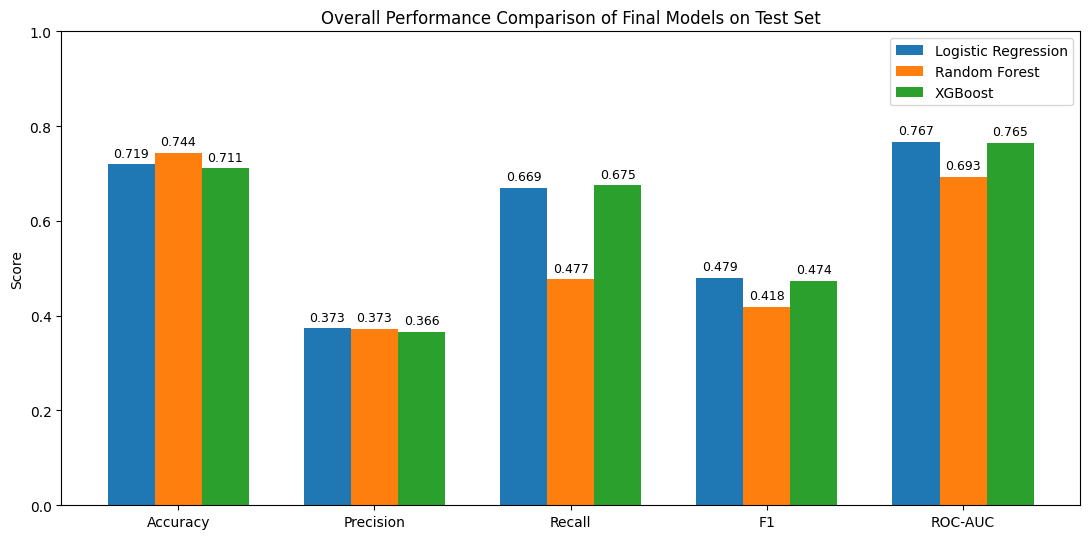

In [124]:
overall_plot_df = test_results_df[
    ['model', 'test_accuracy', 'test_precision', 'test_recall', 'test_f1', 'test_roc_auc']
].copy()

# Rename models for cleaner labels
model_name_map = {
    'LR_Model4': 'Logistic Regression',
    'RF_Model4': 'Random Forest',
    'XGB_Model4': 'XGBoost'
}
overall_plot_df['model'] = overall_plot_df['model'].map(model_name_map)

# Set model order
model_order = ['Logistic Regression', 'Random Forest', 'XGBoost']
overall_plot_df = overall_plot_df.set_index('model').loc[model_order]

# Metrics to display
metrics = ['test_accuracy', 'test_precision', 'test_recall', 'test_f1', 'test_roc_auc']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']

# Plot
x = np.arange(len(metric_labels))
width = 0.24

fig, ax = plt.subplots(figsize=(11, 5.5))

for i, model in enumerate(overall_plot_df.index):
    values = overall_plot_df.loc[model, metrics].values
    bars = ax.bar(x + (i - 1) * width, values, width=width, label=model)

    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{val:.3f}',
            ha='center',
            va='bottom',
            fontsize=9
        )

ax.set_xticks(x)
ax.set_xticklabels(metric_labels)
ax.set_ylim(0, 1.0)
ax.set_ylabel('Score')
ax.set_title('Overall Performance Comparison of Final Models on Test Set')
ax.legend()
plt.tight_layout()
plt.show()

The overall comparison shows that the three final models differ in a clear and meaningful way. Random Forest has the highest accuracy at 0.744, but this comes with much lower recall (0.477), F1 score (0.418), and ROC-AUC (0.693), which means it is less effective at identifying poor health cases despite classifying more observations correctly overall. Logistic Regression and XGBoost are much more competitive for the main project goal. XGBoost achieves the highest recall at 0.675, while Logistic Regression has the highest F1 score (0.479) and the highest ROC-AUC (0.767). Precision is very similar across all three models, with Logistic Regression and Random Forest essentially tied and XGBoost only slightly lower. Overall, the figure suggests that Logistic Regression provides the most balanced final performance, XGBoost performs very similarly and is slightly stronger on recall, and Random Forest is less suitable when the goal is to identify individuals at higher risk of poor health.

### **Key Access Barrier Comparison**

To connect the modeling results more directly to the research questions, we next compare the main healthcare access–related predictors using a common descriptive metric. For each variable, we calculate the difference between the highest and lowest observed poor health rate across its categories. Larger gaps indicate stronger descriptive separation and help show which access-related factors appear most important in identifying poor health risk.

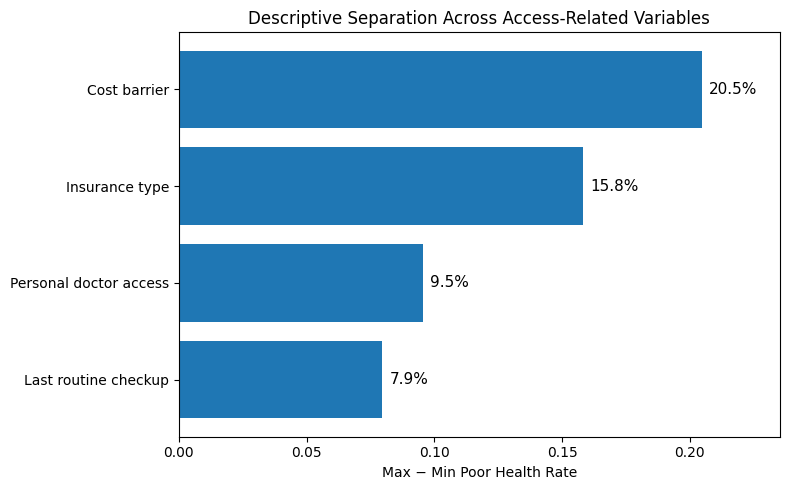

In [122]:
def get_separation(df, var, target='poor_health'):
    temp = df[[var, target]].dropna()
    rates = temp.groupby(var)[target].mean()
    return rates.max() - rates.min()

access_vars = {
    'insurance_type_grouped': 'Insurance type',
    'cost_barrier': 'Cost barrier',
    'has_personal_doctor': 'Personal doctor access',
    'last_checkup_time': 'Last routine checkup'
}

access_results = []
for var, label in access_vars.items():
    sep = get_separation(model_df, var)
    access_results.append({
        'Variable': label,
        'Separation': sep
    })

access_df = pd.DataFrame(access_results)
access_df = access_df.sort_values('Separation', ascending=True)

plt.figure(figsize=(8, 5))
bars = plt.barh(access_df['Variable'], access_df['Separation'])

plt.title('Descriptive Separation Across Access-Related Variables')
plt.xlabel('Max − Min Poor Health Rate')
plt.ylabel('')

for bar, v in zip(bars, access_df['Separation']):
    plt.text(
        v + 0.003,
        bar.get_y() + bar.get_height() / 2,
        f'{v:.1%}',
        va='center',
        fontsize=11
    )

plt.xlim(0, access_df['Separation'].max() * 1.15)
plt.tight_layout()
plt.show()

The figure shows that cost barrier has the largest descriptive separation among the access-related variables, with a gap of 20.5 percentage points between the highest and lowest poor health rates. This makes it the strongest access-related signal in the dataset. Insurance type also shows meaningful separation at 15.8 percentage points, but the gap is still clearly smaller than that of cost barrier. Personal doctor access and last routine checkup show more limited separation, at 9.5 and 7.9 percentage points respectively. Overall, this pattern suggests that affordability-related barriers matter more than the other access variables, which supports the conclusion that cost-related access problems are especially important for identifying poor health risk.

### **SES Effect Summary**

Because the layered model comparison showed that the largest performance gain occurs when SES variables are introduced, we next examine the main socioeconomic predictors directly. As in the access comparison, we use descriptive separation to compare how strongly each SES-related variable differentiates poor health risk across its categories.

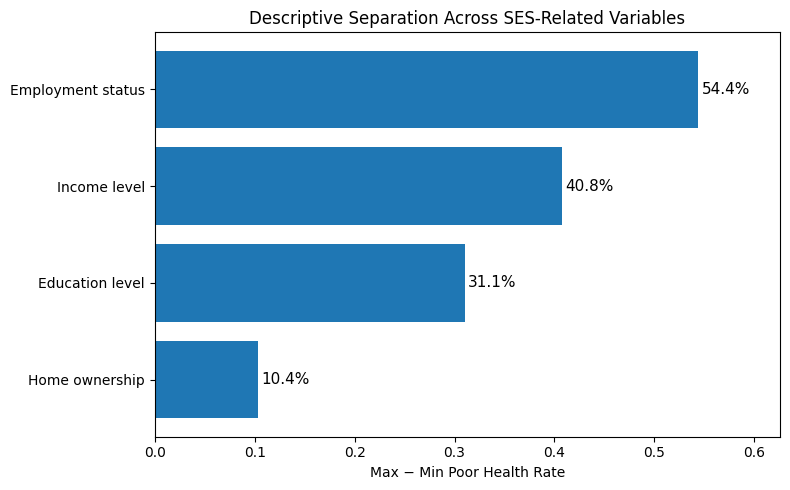

In [123]:
def get_separation(df, var, target='poor_health'):
    temp = df[[var, target]].dropna()
    rates = temp.groupby(var)[target].mean()
    return rates.max() - rates.min()

ses_vars = {
    'income_level': 'Income level',
    'education_level': 'Education level',
    'employment_status': 'Employment status',
    'home_ownership': 'Home ownership'
}

ses_results = []
for var, label in ses_vars.items():
    sep = get_separation(model_df, var)
    ses_results.append({
        'Variable': label,
        'Separation': sep
    })

ses_df = pd.DataFrame(ses_results)
ses_df = ses_df.sort_values('Separation', ascending=True)

plt.figure(figsize=(8, 5))
bars = plt.barh(ses_df['Variable'], ses_df['Separation'])

plt.title('Descriptive Separation Across SES-Related Variables')
plt.xlabel('Max − Min Poor Health Rate')
plt.ylabel('')

for bar, v in zip(bars, ses_df['Separation']):
    plt.text(
        v + 0.003,
        bar.get_y() + bar.get_height() / 2,
        f'{v:.1%}',
        va='center',
        fontsize=11
    )

plt.xlim(0, ses_df['Separation'].max() * 1.15)
plt.tight_layout()
plt.show()

The SES comparison shows that employment status produces the largest descriptive separation by a wide margin, with a 54.4 percentage-point gap between the highest and lowest poor health rates. Income level also shows very strong separation at 40.8 percentage points, followed by education level at 31.1 percentage points. In contrast, home ownership contributes much less separation, at 10.4 percentage points. This pattern helps explain why Model 3 produced the largest improvement in the layered modeling framework: the strongest socioeconomic predictors, especially employment, income, and education, provide much more information about poor health risk than insurance-related variables alone. Overall, the figure suggests that socioeconomic disadvantage is a central part of poor health prediction in this project, rather than just a secondary supplement to access and insurance factors.